In [3]:
#!/usr/bin/env python3

import os
import re
import csv
import subprocess
from multiprocessing import cpu_count

import pandas as pd

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
NUCMER_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer"
GRAPH_DIR = os.path.join(NUCMER_DIR, "graph_cov90_noclose")
CONTAINMENT_FILE = os.path.join(GRAPH_DIR, "containment_NUC_levelup_strictlen.tsv")

PLASMID_FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"
SAMTOOLS = "/home/nacho/mambaforge/envs/samtools/bin/samtools"

# rehacer solo los que faltan
HALF_WINDOWS = [1500, 2000, 2500, 3000]

# ============================================================
# HELPERS
# ============================================================

def parse_cov90_line(line):
    toks = re.split(r"\s+", line.strip())
    if len(toks) < 14:
        return None
    try:
        return {
            "s1": int(toks[0]),
            "e1": int(toks[1]),
            "s2": int(toks[2]),
            "e2": int(toks[3]),
            "len1": int(toks[4]),
            "len2": int(toks[5]),
            "lenR": int(toks[7]),
            "lenQ": int(toks[8]),
            "ref": toks[11],
            "qry": toks[12],
            "raw": line.strip(),
        }
    except Exception:
        return None

def get_cov90_path(src):
    p1 = os.path.join(NUCMER_DIR, src)
    if os.path.exists(p1):
        return p1
    p2 = os.path.join(GRAPH_DIR, os.path.basename(src))
    if os.path.exists(p2):
        return p2
    raise FileNotFoundError(f"No encuentro cov90 para: {src}")

def get_fasta_path(chrom):
    for fname in os.listdir(PLASMID_FASTA_DIR):
        if fname.endswith((".fna", ".fa", ".fasta")) and fname.startswith(chrom):
            return os.path.join(PLASMID_FASTA_DIR, fname)
    return None

def get_length_from_fasta(fasta):
    fai = fasta + ".fai"
    if not os.path.exists(fai):
        subprocess.run([SAMTOOLS, "faidx", fasta], check=True)
    with open(fai) as f:
        return int(f.readline().split("\t")[1])

def normalize_circular_pos(center, L):
    """
    Fuerza una coordenada a estar en 1..L en un círculo.
    """
    return ((int(center) - 1) % int(L)) + 1

def circular_window(center, L, hw):
    """
    Devuelve una o dos regiones válidas en coordenadas 1-based cerradas.
    Siempre garantiza:
      1 <= start <= end <= L
    """
    L = int(L)
    hw = int(hw)
    center = normalize_circular_pos(center, L)

    start = center - hw
    end = center + hw

    # caso simple: no cruza borde
    if start >= 1 and end <= L:
        return [(start, end)]

    parts = []

    # lado izquierdo cruza el origen
    if start < 1:
        left_start = L + start + 1
        left_end = L
        right_start = 1
        right_end = end

        if 1 <= left_start <= left_end <= L:
            parts.append((left_start, left_end))
        if 1 <= right_start <= right_end <= L:
            parts.append((right_start, right_end))

        return parts if parts else None

    # lado derecho cruza el final
    if end > L:
        left_start = start
        left_end = L
        right_start = 1
        right_end = end - L

        if 1 <= left_start <= left_end <= L:
            parts.append((left_start, left_end))
        if 1 <= right_start <= right_end <= L:
            parts.append((right_start, right_end))

        return parts if parts else None

    return None

def fetch_sequence(fasta, chrom, parts):
    seq = []
    for s, e in parts:
        s = int(s)
        e = int(e)

        if not (1 <= s <= e):
            raise ValueError(f"Invalid interval before faidx: {chrom}:{s}-{e}")

        region = f"{chrom}:{s}-{e}"
        out = subprocess.check_output([SAMTOOLS, "faidx", fasta, region]).decode()
        seq.append("".join(out.split("\n")[1:]))

    return "".join(seq)

# ============================================================
# MAIN
# ============================================================

print("Building missing traceable windows with robust circular coordinates...")
print("Half-windows:", HALF_WINDOWS)

for WINDOW_HW in HALF_WINDOWS:
    print("\n============================================================")
    print(f"WINDOW_HW = {WINDOW_HW}")
    print("============================================================")

    OUTDIR = os.path.join(BASE_DIR, f"TRACEABLE_hardcut_95pid_{WINDOW_HW}_onebest_per_pair")
    WINDOWS_DIR = os.path.join(OUTDIR, "windows")

    MASTER_TSV = os.path.join(OUTDIR, "breakpoints_master.tsv")
    MULTIFASTA = os.path.join(OUTDIR, "breakpoints_windows.fa")

    os.makedirs(OUTDIR, exist_ok=True)
    os.makedirs(WINDOWS_DIR, exist_ok=True)

    if os.path.exists(MASTER_TSV) and os.path.exists(MULTIFASTA):
        print(f"[SKIP] Ya existen:")
        print(f"  {MASTER_TSV}")
        print(f"  {MULTIFASTA}")
        continue

    rows = []
    pair_id = 0
    bp_index = 0
    n_skipped_invalid = 0

    with open(CONTAINMENT_FILE) as f:
        rdr = csv.DictReader(f, delimiter="\t")
        for row in rdr:
            big_len = int(row["big_len"])
            cov_path = get_cov90_path(row["source_file"])

            found = False
            with open(cov_path) as fh:
                for lineno, line in enumerate(fh, 1):
                    parsed = parse_cov90_line(line)
                    if not parsed:
                        continue

                    if parsed["lenR"] == big_len:
                        chrom = parsed["ref"]
                        s = min(parsed["s1"], parsed["e1"])
                        e = max(parsed["s1"], parsed["e1"])
                    elif parsed["lenQ"] == big_len:
                        chrom = parsed["qry"]
                        s = min(parsed["s2"], parsed["e2"])
                        e = max(parsed["s2"], parsed["e2"])
                    else:
                        continue

                    fasta = get_fasta_path(chrom)
                    if fasta is None:
                        print(f"[WARN] No FASTA for {chrom}")
                        break

                    real_L = get_length_from_fasta(fasta)

                    ok_this_pair = True
                    pair_rows = []

                    for bp_kind, pos in [("start", s), ("end", e)]:
                        pos_norm = normalize_circular_pos(pos, real_L)
                        parts = circular_window(pos_norm, real_L, WINDOW_HW)

                        if not parts:
                            ok_this_pair = False
                            break

                        try:
                            seq = fetch_sequence(fasta, chrom, parts)
                        except Exception as ex:
                            print(f"[WARN] failed extracting {chrom} {bp_kind} pos={pos} norm={pos_norm} L={real_L}: {ex}")
                            ok_this_pair = False
                            break

                        header = (
                            f"pair={pair_id}|bp={bp_index}|plasmid={chrom}"
                            f"|kind={bp_kind}|pos={pos_norm}|hw={WINDOW_HW}"
                        )

                        fa_path = os.path.join(WINDOWS_DIR, f"bp_{bp_index}.fa")
                        with open(fa_path, "w") as out:
                            out.write(f">{header}\n{seq}\n")

                        pair_rows.append({
                            "pair_id": pair_id,
                            "bp_index": bp_index,
                            "plasmid": chrom,
                            "breakpoint_pos": pos_norm,
                            "breakpoint_pos_raw": int(pos),
                            "bp_kind": bp_kind,
                            "plasmid_len": real_L,
                            "window_hw": WINDOW_HW,
                            "breakpoint_winpos": WINDOW_HW + 1,
                            "source_file": row["source_file"],
                            "containment_query": row["query_id"],
                            "containment_target": row["target_id"],
                            "cov_line_number": lineno,
                            "fasta_header": header,
                            "fasta_path": fa_path,
                        })
                        bp_index += 1

                    if ok_this_pair:
                        rows.extend(pair_rows)
                        pair_id += 1
                    else:
                        n_skipped_invalid += 1

                    found = True
                    break

            if not found:
                print(f"[WARN] No valid alignment for {row['query_id']} vs {row['target_id']}")

    master = pd.DataFrame(rows)

    if master.empty:
        print("[ERROR] No se generó ninguna ventana.")
        continue

    master.to_csv(MASTER_TSV, sep="\t", index=False)

    with open(MULTIFASTA, "w") as out:
        for _, r in master.sort_values("bp_index").iterrows():
            with open(r["fasta_path"]) as f:
                out.write(f.read())

    print(f"Breakpoints: {len(master)}")
    print(f"Pairs: {master['pair_id'].nunique()}")
    print(f"Unique plasmids: {master['plasmid'].nunique()}")
    print(f"Skipped invalid pairs: {n_skipped_invalid}")
    print(f"Wrote: {MASTER_TSV}")
    print(f"Wrote: {MULTIFASTA}")

print("\nDONE.")

Building missing traceable windows with robust circular coordinates...
Half-windows: [1500, 2000, 2500, 3000]

WINDOW_HW = 1500
Breakpoints: 3234
Pairs: 1617
Unique plasmids: 1009
Skipped invalid pairs: 0
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_1500_onebest_per_pair/breakpoints_master.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_1500_onebest_per_pair/breakpoints_windows.fa

WINDOW_HW = 2000
Breakpoints: 3234
Pairs: 1617
Unique plasmids: 1009
Skipped invalid pairs: 0
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/breakpoints_master.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/breakpoints_windows.fa

WINDOW_HW = 2500
Breakpoints: 3234
Pairs: 1617
Unique plasmids: 1009
Skipped invalid pairs: 0
Wrote: /home/nacho/HDD16/Nacho/Re

Parsing HW=500
Parsing HW=1000
Parsing HW=1500
Parsing HW=2000
Parsing HW=2500
Parsing HW=3000

Saved all tables in:
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/MEFINDER_pairwise_summary_v2


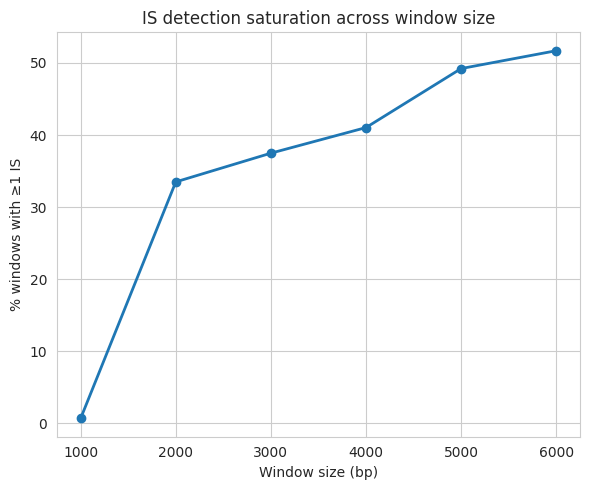

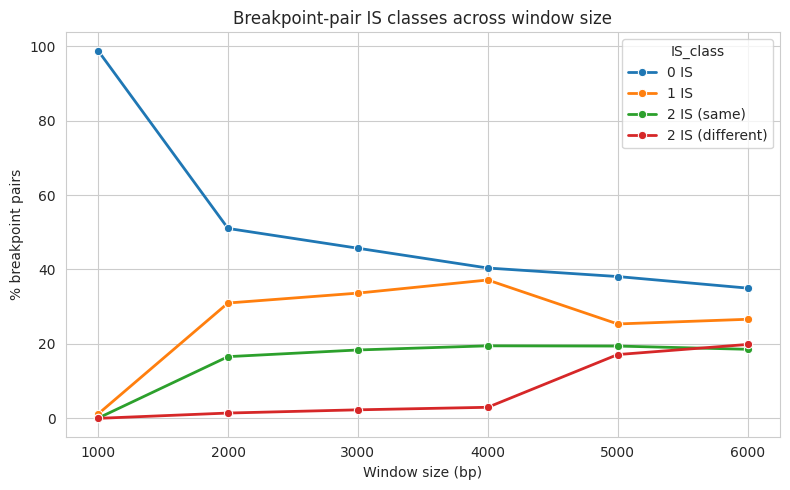

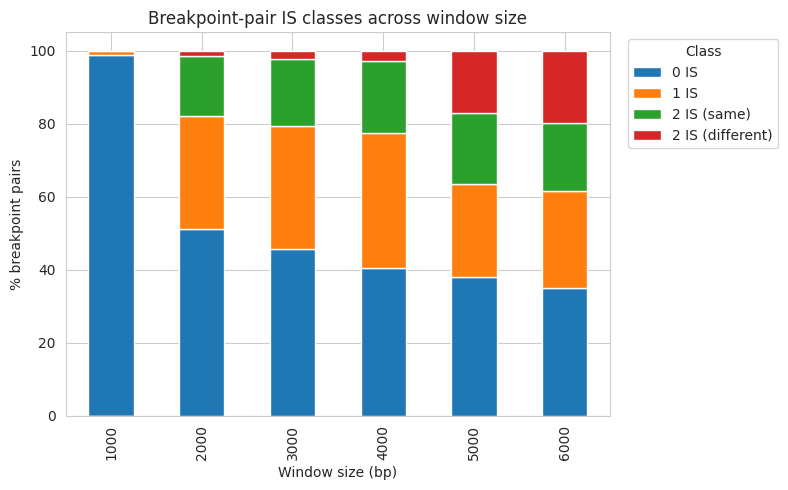

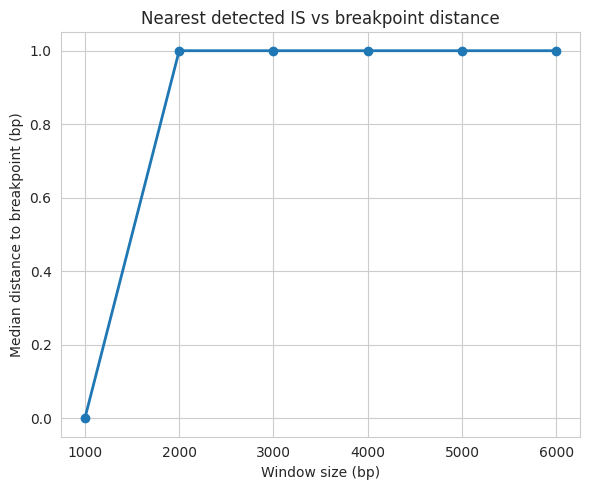

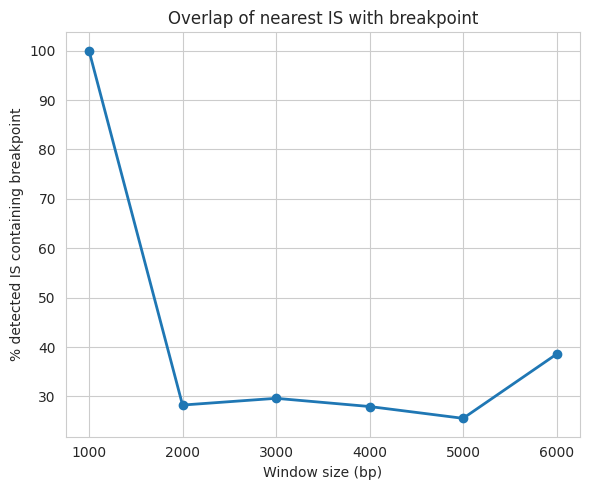


DONE.


In [23]:
#!/usr/bin/env python3

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
HWS = [500, 1000, 1500, 2000, 2500, 3000]

OUTDIR = os.path.join(BASE, "MEFINDER_pairwise_summary_v2")
os.makedirs(OUTDIR, exist_ok=True)

sns.set_style("whitegrid")

IS_NAME_CANDIDATES = [
    "name", "element", "is_name", "IS", "family", "subtype", "type"
]

START_CANDIDATES = ["start", "begin", "from", "qstart"]
END_CANDIDATES   = ["end", "stop", "to", "qend"]

CLASS_ORDER = ["0 IS", "1 IS", "2 IS (same)", "2 IS (different)"]

# ============================================================
# HELPERS
# ============================================================

def pick_column(df, candidates):
    low = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in low:
            return low[cand.lower()]
    return None

def read_mefinder_csv(path):
    if not os.path.exists(path):
        return None
    if os.path.getsize(path) == 0:
        return None
    try:
        df = pd.read_csv(path, sep=",", comment="#")
    except Exception:
        return None
    return df

def nearest_is_to_breakpoint(df, breakpoint_pos):
    """
    Devuelve la IS más cercana al breakpoint.
    Si hay varias, se queda con la de menor distancia mínima al breakpoint.
    """
    if df is None or df.empty:
        return None

    name_col = pick_column(df, IS_NAME_CANDIDATES)
    start_col = pick_column(df, START_CANDIDATES)
    end_col = pick_column(df, END_CANDIDATES)

    if name_col is None or start_col is None or end_col is None:
        return None

    x = df.copy()
    x[start_col] = pd.to_numeric(x[start_col], errors="coerce")
    x[end_col] = pd.to_numeric(x[end_col], errors="coerce")
    x = x.dropna(subset=[start_col, end_col]).copy()

    if x.empty:
        return None

    x["_start"] = x[[start_col, end_col]].min(axis=1)
    x["_end"] = x[[start_col, end_col]].max(axis=1)
    x["bp_inside"] = (x["_start"] <= breakpoint_pos) & (x["_end"] >= breakpoint_pos)

    x["dist_to_bp"] = np.where(
        x["bp_inside"],
        0,
        np.minimum(
            np.abs(x["_start"] - breakpoint_pos),
            np.abs(x["_end"] - breakpoint_pos)
        )
    )

    best = x.sort_values(
        ["dist_to_bp", "bp_inside"],
        ascending=[True, False]
    ).iloc[0]

    return {
        "is_name": str(best[name_col]),
        "is_start_window": int(best["_start"]),
        "is_end_window": int(best["_end"]),
        "bp_inside": bool(best["bp_inside"]),
        "dist_to_bp": int(best["dist_to_bp"]),
        "n_hits_in_window": int(len(x))
    }

def classify_pair(row):
    s = bool(row["start_has_is"])
    e = bool(row["end_has_is"])

    if (not s) and (not e):
        return "0 IS"
    if s ^ e:
        return "1 IS"
    if str(row["start_is_name"]) == str(row["end_is_name"]):
        return "2 IS (same)"
    return "2 IS (different)"

# ============================================================
# MAIN PARSE
# ============================================================

all_window_rows = []
all_pair_rows = []
summary_rows = []

for hw in HWS:
    print(f"Parsing HW={hw}")

    trace_dir = os.path.join(BASE, f"TRACEABLE_hardcut_95pid_{hw}_onebest_per_pair")
    master_tsv = os.path.join(trace_dir, "breakpoints_master.tsv")
    mefinder_dir = os.path.join(trace_dir, "mefinder_windows_v2")

    if not os.path.exists(master_tsv):
        print(f"[WARN] missing {master_tsv}")
        continue

    if not os.path.isdir(mefinder_dir):
        print(f"[WARN] missing {mefinder_dir}")
        continue

    master = pd.read_csv(master_tsv, sep="\t")
    breakpoint_winpos = hw + 1

    # --------------------------------------------------------
    # window-level parse
    # --------------------------------------------------------
    window_rows = []

    for _, r in master.iterrows():
        bp_index = int(r["bp_index"])
        pair_id = int(r["pair_id"])
        plasmid = r["plasmid"]
        bp_kind = r["bp_kind"]

        csv_path = os.path.join(mefinder_dir, f"hw{hw}_bp_{bp_index}.csv")
        df_me = read_mefinder_csv(csv_path)
        best_is = nearest_is_to_breakpoint(df_me, breakpoint_winpos)

        window_rows.append({
            "window_hw": hw,
            "window_size": 2 * hw,
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_kind": bp_kind,
            "bp_index": bp_index,
            "breakpoint_pos_genome": int(r["breakpoint_pos"]),
            "breakpoint_pos_window": breakpoint_winpos,
            "mefinder_csv": csv_path,
            "has_is": best_is is not None,
            "nearest_is_name": None if best_is is None else best_is["is_name"],
            "nearest_is_start_window": None if best_is is None else best_is["is_start_window"],
            "nearest_is_end_window": None if best_is is None else best_is["is_end_window"],
            "nearest_is_bp_inside": None if best_is is None else best_is["bp_inside"],
            "nearest_is_dist_to_bp": None if best_is is None else best_is["dist_to_bp"],
            "n_hits_in_window": 0 if best_is is None else best_is["n_hits_in_window"],
        })

    window_df = pd.DataFrame(window_rows)
    window_df.to_csv(
        os.path.join(OUTDIR, f"window_annotations_hw{hw}.tsv"),
        sep="\t",
        index=False
    )

    # --------------------------------------------------------
    # pair-level collapse
    # --------------------------------------------------------
    start_df = (
        window_df[window_df["bp_kind"] == "start"]
        .copy()
        .rename(columns={
            "bp_index": "bp_index_start",
            "breakpoint_pos_genome": "bp_start_pos",
            "has_is": "start_has_is",
            "nearest_is_name": "start_is_name",
            "nearest_is_start_window": "start_is_start_window",
            "nearest_is_end_window": "start_is_end_window",
            "nearest_is_bp_inside": "start_is_bp_inside",
            "nearest_is_dist_to_bp": "start_is_dist_to_bp",
            "n_hits_in_window": "start_n_hits_in_window",
            "mefinder_csv": "start_mefinder_csv",
        })
    )

    end_df = (
        window_df[window_df["bp_kind"] == "end"]
        .copy()
        .rename(columns={
            "bp_index": "bp_index_end",
            "breakpoint_pos_genome": "bp_end_pos",
            "has_is": "end_has_is",
            "nearest_is_name": "end_is_name",
            "nearest_is_start_window": "end_is_start_window",
            "nearest_is_end_window": "end_is_end_window",
            "nearest_is_bp_inside": "end_is_bp_inside",
            "nearest_is_dist_to_bp": "end_is_dist_to_bp",
            "n_hits_in_window": "end_n_hits_in_window",
            "mefinder_csv": "end_mefinder_csv",
        })
    )

    pair_df = start_df.merge(
        end_df,
        on=["window_hw", "window_size", "pair_id", "plasmid"],
        how="inner"
    )

    pair_df["IS_class"] = pair_df.apply(classify_pair, axis=1)

    pair_df.to_csv(
        os.path.join(OUTDIR, f"pair_classification_hw{hw}.tsv"),
        sep="\t",
        index=False
    )

    # --------------------------------------------------------
    # summaries
    # --------------------------------------------------------
    class_counts = (
        pair_df["IS_class"]
        .value_counts()
        .rename_axis("IS_class")
        .reset_index(name="n_pairs")
    )
    class_counts["window_hw"] = hw
    class_counts["window_size"] = 2 * hw
    class_counts["pct_pairs"] = 100 * class_counts["n_pairs"] / class_counts["n_pairs"].sum()

    class_counts.to_csv(
        os.path.join(OUTDIR, f"class_counts_hw{hw}.tsv"),
        sep="\t",
        index=False
    )

    summary_rows.append({
        "window_hw": hw,
        "window_size": 2 * hw,
        "n_windows": len(window_df),
        "n_windows_with_is": int(window_df["has_is"].sum()),
        "pct_windows_with_is": 100 * window_df["has_is"].mean(),
        "n_pairs": len(pair_df),
        "n_pairs_0IS": int((pair_df["IS_class"] == "0 IS").sum()),
        "n_pairs_1IS": int((pair_df["IS_class"] == "1 IS").sum()),
        "n_pairs_2IS_same": int((pair_df["IS_class"] == "2 IS (same)").sum()),
        "n_pairs_2IS_different": int((pair_df["IS_class"] == "2 IS (different)").sum()),
        "pct_pairs_0IS": 100 * (pair_df["IS_class"] == "0 IS").mean(),
        "pct_pairs_1IS": 100 * (pair_df["IS_class"] == "1 IS").mean(),
        "pct_pairs_2IS_same": 100 * (pair_df["IS_class"] == "2 IS (same)").mean(),
        "pct_pairs_2IS_different": 100 * (pair_df["IS_class"] == "2 IS (different)").mean(),
        "median_dist_detected_is": float(window_df.loc[window_df["has_is"], "nearest_is_dist_to_bp"].median())
            if window_df["has_is"].any() else np.nan,
        "pct_detected_is_bp_inside": 100 * window_df.loc[window_df["has_is"], "nearest_is_bp_inside"].mean()
            if window_df["has_is"].any() else np.nan,
    })

    all_window_rows.append(window_df)
    all_pair_rows.append(pair_df)

# ============================================================
# SAVE COMBINED TABLES
# ============================================================

all_windows_df = pd.concat(all_window_rows, ignore_index=True)
all_pairs_df = pd.concat(all_pair_rows, ignore_index=True)
summary_df = pd.DataFrame(summary_rows)

all_windows_df.to_csv(os.path.join(OUTDIR, "all_window_annotations.tsv"), sep="\t", index=False)
all_pairs_df.to_csv(os.path.join(OUTDIR, "all_pair_classifications.tsv"), sep="\t", index=False)
summary_df.to_csv(os.path.join(OUTDIR, "summary_global.tsv"), sep="\t", index=False)

# ============================================================
# COMPLETE CLASS SUMMARY ACROSS ALL WINDOW SIZES
# ============================================================

summary_classes_df = (
    all_pairs_df.groupby(["window_size", "window_hw", "IS_class"])
    .size()
    .reset_index(name="n_pairs")
)

# tabla completa con todas las clases en todos los tamaños
all_window_sizes = (
    all_pairs_df[["window_size", "window_hw"]]
    .drop_duplicates()
    .sort_values("window_size")
    .reset_index(drop=True)
)

complete_index = (
    all_window_sizes.assign(key=1)
    .merge(pd.DataFrame({"IS_class": CLASS_ORDER, "key": 1}), on="key")
    .drop(columns="key")
)

summary_classes_complete = complete_index.merge(
    summary_classes_df,
    on=["window_size", "window_hw", "IS_class"],
    how="left"
)

summary_classes_complete["n_pairs"] = summary_classes_complete["n_pairs"].fillna(0).astype(int)

summary_classes_complete["pct_pairs"] = (
    100 * summary_classes_complete["n_pairs"] /
    summary_classes_complete.groupby("window_size")["n_pairs"].transform("sum")
)

summary_classes_complete.to_csv(
    os.path.join(OUTDIR, "summary_classes.tsv"),
    sep="\t",
    index=False
)

print("\nSaved all tables in:")
print(OUTDIR)

# ============================================================
# PLOTS
# ============================================================

# 1. % windows with >=1 IS
plt.figure(figsize=(6, 5))
plt.plot(
    summary_df["window_size"],
    summary_df["pct_windows_with_is"],
    marker="o",
    linewidth=2
)
plt.xlabel("Window size (bp)")
plt.ylabel("% windows with ≥1 IS")
plt.title("IS detection saturation across window size")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "plot_windows_with_is.png"), dpi=300, bbox_inches="tight")
plt.show()

# 2. Four class curves across all window sizes
plot_df = summary_classes_complete.copy()
plot_df["IS_class"] = pd.Categorical(
    plot_df["IS_class"],
    categories=CLASS_ORDER,
    ordered=True
)
plot_df = plot_df.sort_values(["window_size", "IS_class"])

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=plot_df,
    x="window_size",
    y="pct_pairs",
    hue="IS_class",
    hue_order=CLASS_ORDER,
    marker="o",
    linewidth=2
)
plt.xlabel("Window size (bp)")
plt.ylabel("% breakpoint pairs")
plt.title("Breakpoint-pair IS classes across window size")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "plot_pair_classes_lines.png"), dpi=300, bbox_inches="tight")
plt.show()

# 3. Stacked bars of pair classes
stack_df = (
    plot_df.pivot(index="window_size", columns="IS_class", values="pct_pairs")
    .fillna(0)
    .reindex(columns=CLASS_ORDER)
)

ax = stack_df.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)
ax.set_xlabel("Window size (bp)")
ax.set_ylabel("% breakpoint pairs")
ax.set_title("Breakpoint-pair IS classes across window size")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "plot_pair_classes_stacked.png"), dpi=300, bbox_inches="tight")
plt.show()

# 4. Median distance to breakpoint among detected IS
plt.figure(figsize=(6, 5))
plt.plot(
    summary_df["window_size"],
    summary_df["median_dist_detected_is"],
    marker="o",
    linewidth=2
)
plt.xlabel("Window size (bp)")
plt.ylabel("Median distance to breakpoint (bp)")
plt.title("Nearest detected IS vs breakpoint distance")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "plot_median_distance.png"), dpi=300, bbox_inches="tight")
plt.show()

# 5. % detected IS overlapping breakpoint
plt.figure(figsize=(6, 5))
plt.plot(
    summary_df["window_size"],
    summary_df["pct_detected_is_bp_inside"],
    marker="o",
    linewidth=2
)
plt.xlabel("Window size (bp)")
plt.ylabel("% detected IS containing breakpoint")
plt.title("Overlap of nearest IS with breakpoint")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "plot_bp_inside.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nDONE.")

In [22]:
import os
import pandas as pd

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
PAIRWISE_DIR = os.path.join(BASE, "MEFINDER_pairwise_summary_v2")
HWS = [500, 1000, 1500, 2000, 2500, 3000]

# ------------------------------------------------------------
# 1. cargar conjuntos de "2 IS (same)"
# ------------------------------------------------------------
same_sets = {}

for hw in HWS:
    pair_file = os.path.join(PAIRWISE_DIR, f"pair_classification_hw{hw}.tsv")
    df = pd.read_csv(pair_file, sep="\t")

    same_ids = set(df.loc[df["IS_class"] == "2 IS (same)", "pair_id"].astype(int))
    same_sets[hw] = same_ids

# ------------------------------------------------------------
# 2. intersección (pares estables en todas las ventanas)
# ------------------------------------------------------------
common_same_all = set.intersection(*same_sets.values())
print("Stable pairs across all windows:", len(common_same_all))

# ------------------------------------------------------------
# 3. construir audit_df
# ------------------------------------------------------------
rows = []

for hw in HWS:
    pair_file = os.path.join(PAIRWISE_DIR, f"pair_classification_hw{hw}.tsv")
    df = pd.read_csv(pair_file, sep="\t")

    df = df[df["pair_id"].isin(common_same_all)].copy()
    df = df[df["IS_class"] == "2 IS (same)"].copy()

    cols = [
        "pair_id", "plasmid",
        "start_is_name", "end_is_name",
        "start_is_start_window", "start_is_end_window",
        "end_is_start_window", "end_is_end_window",
        "start_is_dist_to_bp", "end_is_dist_to_bp",
        "start_is_bp_inside", "end_is_bp_inside"
    ]

    present = [c for c in cols if c in df.columns]
    x = df[present].copy()

    x["hw"] = hw
    x["window_size"] = 2 * hw

    rows.append(x)

audit_df = pd.concat(rows, ignore_index=True)

print(audit_df.shape)
audit_df.head()

Stable pairs across all windows: 1
(6, 14)


,pair_id,plasmid,start_is_name,end_is_name,start_is_start_window,start_is_end_window,end_is_start_window,end_is_end_window,start_is_dist_to_bp,end_is_dist_to_bp,start_is_bp_inside,end_is_bp_inside,hw,window_size
0,868,NZ_ON390812.1,IS26,IS26,144.0,963.0,145.0,964.0,0.0,0.0,True,True,500,1000
1,868,NZ_ON390812.1,IS26,IS26,644.0,1463.0,645.0,1464.0,0.0,0.0,True,True,1000,2000
2,868,NZ_ON390812.1,IS26,IS26,1144.0,1963.0,1145.0,1964.0,0.0,0.0,True,True,1500,3000
3,868,NZ_ON390812.1,IS26,IS26,1644.0,2463.0,1645.0,2464.0,0.0,0.0,True,True,2000,4000
4,868,NZ_ON390812.1,IS26,IS26,2144.0,2963.0,2145.0,2964.0,0.0,0.0,True,True,2500,5000


Total pairs with 2 IS (same): 1494
Total IS observations (start + end): 2988

Summary by window size:
   window_size  count        mean         std  min  25%  50%   75%     max
0         1000    2.0    0.000000    0.000000  0.0  0.0  0.0   0.0     0.0
1         2000  536.0    7.764925   32.562991  0.0  0.0  1.0   1.0   234.0
2         3000  594.0   31.907407  100.252244  0.0  0.0  1.0   1.0   746.0
3         4000  630.0   61.850794  199.605995  0.0  0.0  1.0   1.0  1265.0
4         5000  628.0  105.514331  319.410634  0.0  0.0  1.0   1.0  1732.0
5         6000  598.0  271.321070  580.957793  0.0  0.0  1.0  66.0  2106.0


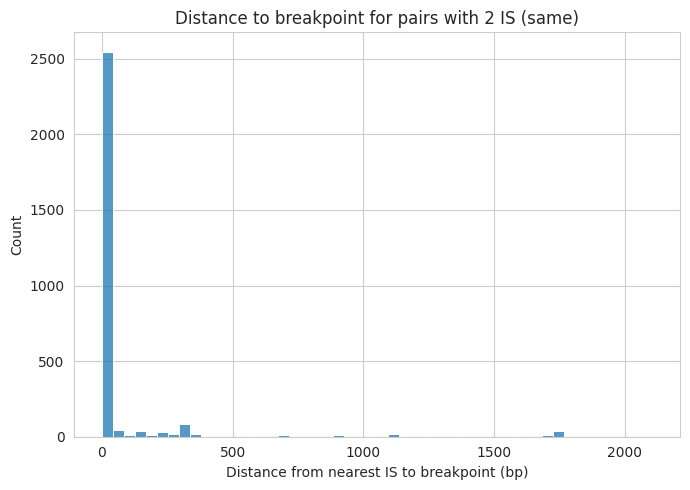

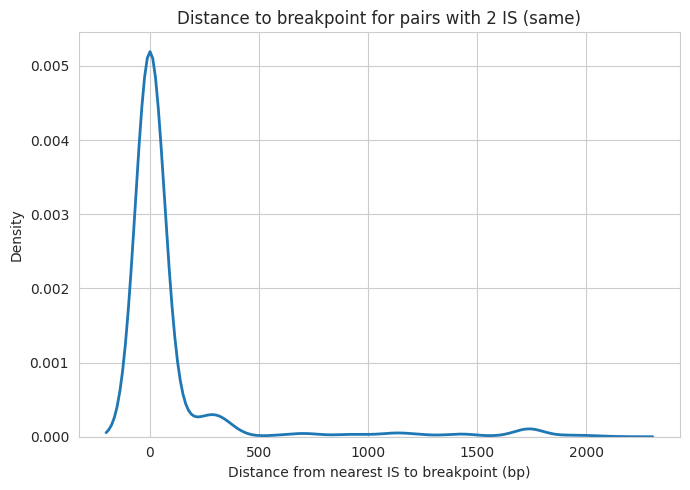

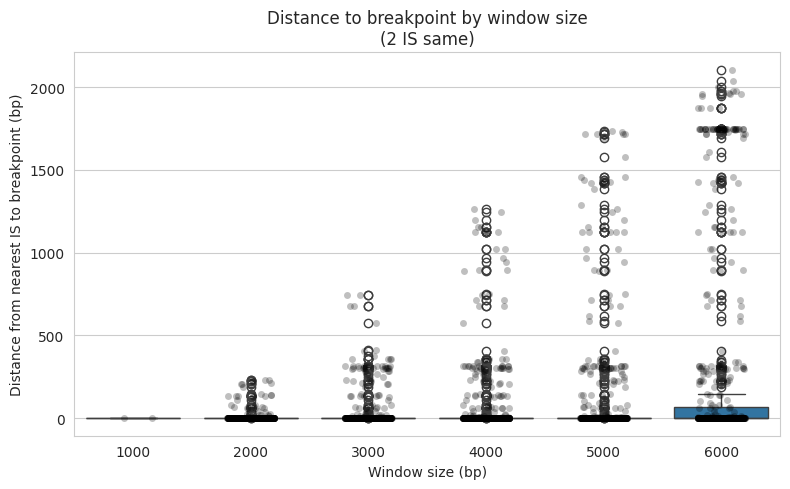

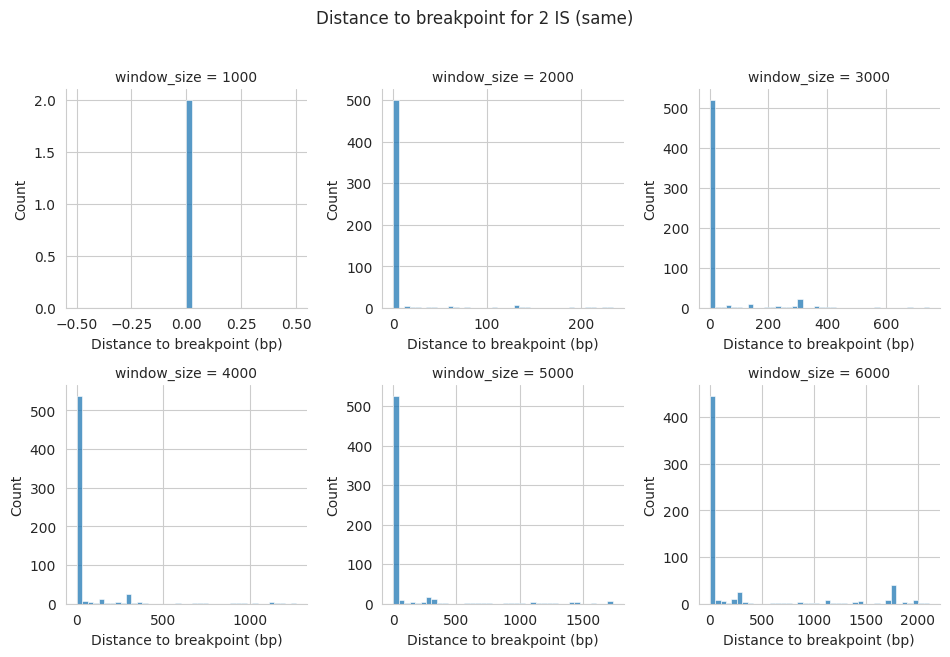

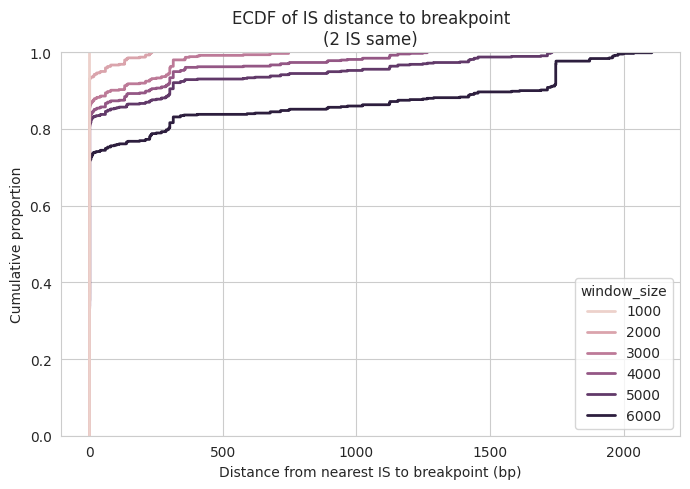


Wrote:
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/MEFINDER_sameIS_distance_to_breakpoint/same_is_distance_to_breakpoint_long.tsv
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/MEFINDER_sameIS_distance_to_breakpoint/same_is_distance_to_breakpoint_summary.tsv
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/MEFINDER_sameIS_distance_to_breakpoint/hist_same_is_distance_global.png
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/MEFINDER_sameIS_distance_to_breakpoint/kde_same_is_distance_global.png
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/MEFINDER_sameIS_distance_to_breakpoint/boxplot_same_is_distance_by_window.png
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/MEFINDER_sameIS_distance_to_breakpoint/hist_same_is_distance_by_window.png
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/MEFINDER_sameIS_distance_to_breakpoint/ecdf_same_is_distance_by_wi

In [12]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
PAIRWISE_DIR = os.path.join(BASE, "MEFINDER_pairwise_summary_v2")
OUTDIR = os.path.join(BASE, "MEFINDER_sameIS_distance_to_breakpoint")
os.makedirs(OUTDIR, exist_ok=True)

sns.set_style("whitegrid")

# ============================================================
# LOAD ALL PAIR TABLES
# ============================================================

files = sorted(glob.glob(os.path.join(PAIRWISE_DIR, "pair_classification_hw*.tsv")))

dfs = []
for f in files:
    df = pd.read_csv(f, sep="\t")
    dfs.append(df)

pairs = pd.concat(dfs, ignore_index=True)

# ============================================================
# KEEP ONLY 2 IS (same)
# ============================================================

same_df = pairs[pairs["IS_class"] == "2 IS (same)"].copy()

print("Total pairs with 2 IS (same):", len(same_df))

# sanity
needed = ["window_hw", "pair_id", "plasmid", "start_is_dist_to_bp", "end_is_dist_to_bp"]
missing = [c for c in needed if c not in same_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# ============================================================
# LONG FORMAT: one row per side
# ============================================================

start_long = same_df[[
    "window_hw", "pair_id", "plasmid", "start_is_dist_to_bp"
]].copy()
start_long = start_long.rename(columns={"start_is_dist_to_bp": "dist_to_bp"})
start_long["side"] = "start"

end_long = same_df[[
    "window_hw", "pair_id", "plasmid", "end_is_dist_to_bp"
]].copy()
end_long = end_long.rename(columns={"end_is_dist_to_bp": "dist_to_bp"})
end_long["side"] = "end"

dist_df = pd.concat([start_long, end_long], ignore_index=True)
dist_df["window_size"] = dist_df["window_hw"] * 2
dist_df["dist_to_bp"] = pd.to_numeric(dist_df["dist_to_bp"], errors="coerce")
dist_df = dist_df.dropna(subset=["dist_to_bp"]).copy()

print("Total IS observations (start + end):", len(dist_df))

# ============================================================
# SAVE LONG TABLE
# ============================================================

dist_df.to_csv(
    os.path.join(OUTDIR, "same_is_distance_to_breakpoint_long.tsv"),
    sep="\t",
    index=False
)

# ============================================================
# SUMMARY
# ============================================================

summary = (
    dist_df.groupby("window_size")["dist_to_bp"]
    .describe()
    .reset_index()
)

print("\nSummary by window size:")
print(summary)

summary.to_csv(
    os.path.join(OUTDIR, "same_is_distance_to_breakpoint_summary.tsv"),
    sep="\t",
    index=False
)

# ============================================================
# 1. GLOBAL HISTOGRAM
# ============================================================

plt.figure(figsize=(7, 5))
sns.histplot(
    data=dist_df,
    x="dist_to_bp",
    bins=50
)
plt.xlabel("Distance from nearest IS to breakpoint (bp)")
plt.ylabel("Count")
plt.title("Distance to breakpoint for pairs with 2 IS (same)")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTDIR, "hist_same_is_distance_global.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 2. GLOBAL KDE
# ============================================================

plt.figure(figsize=(7, 5))
sns.kdeplot(
    data=dist_df,
    x="dist_to_bp",
    linewidth=2
)
plt.xlabel("Distance from nearest IS to breakpoint (bp)")
plt.ylabel("Density")
plt.title("Distance to breakpoint for pairs with 2 IS (same)")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTDIR, "kde_same_is_distance_global.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 3. BOXPLOT BY WINDOW SIZE
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=dist_df,
    x="window_size",
    y="dist_to_bp"
)
sns.stripplot(
    data=dist_df,
    x="window_size",
    y="dist_to_bp",
    color="black",
    alpha=0.25,
    jitter=0.2
)
plt.xlabel("Window size (bp)")
plt.ylabel("Distance from nearest IS to breakpoint (bp)")
plt.title("Distance to breakpoint by window size\n(2 IS same)")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTDIR, "boxplot_same_is_distance_by_window.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 4. HISTOGRAMS FACETED BY WINDOW SIZE
# ============================================================

g = sns.FacetGrid(
    dist_df,
    col="window_size",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=3.2
)
g.map_dataframe(sns.histplot, x="dist_to_bp", bins=40)

for ax in g.axes.flatten():
    ax.set_xlabel("Distance to breakpoint (bp)")
    ax.set_ylabel("Count")

g.fig.suptitle("Distance to breakpoint for 2 IS (same)", y=1.02)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTDIR, "hist_same_is_distance_by_window.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 5. ECDF
# ============================================================

plt.figure(figsize=(7, 5))
sns.ecdfplot(
    data=dist_df,
    x="dist_to_bp",
    hue="window_size",
    linewidth=2
)
plt.xlabel("Distance from nearest IS to breakpoint (bp)")
plt.ylabel("Cumulative proportion")
plt.title("ECDF of IS distance to breakpoint\n(2 IS same)")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTDIR, "ecdf_same_is_distance_by_window.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("\nWrote:")
print(os.path.join(OUTDIR, "same_is_distance_to_breakpoint_long.tsv"))
print(os.path.join(OUTDIR, "same_is_distance_to_breakpoint_summary.tsv"))
print(os.path.join(OUTDIR, "hist_same_is_distance_global.png"))
print(os.path.join(OUTDIR, "kde_same_is_distance_global.png"))
print(os.path.join(OUTDIR, "boxplot_same_is_distance_by_window.png"))
print(os.path.join(OUTDIR, "hist_same_is_distance_by_window.png"))
print(os.path.join(OUTDIR, "ecdf_same_is_distance_by_window.png"))

In [20]:
import os
import pandas as pd

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
PAIRWISE_DIR = os.path.join(BASE, "MEFINDER_pairwise_summary_v2")
HWS = [500, 1000, 1500, 2000, 2500, 3000]

same_sets = {}
summary_rows = []

for hw in HWS:
    pair_file = os.path.join(PAIRWISE_DIR, f"pair_classification_hw{hw}.tsv")
    df = pd.read_csv(pair_file, sep="\t")

    same_ids = set(df.loc[df["IS_class"] == "2 IS (same)", "pair_id"].astype(int))
    same_sets[hw] = same_ids

    summary_rows.append({
        "hw": hw,
        "window_size": 2 * hw,
        "n_same_pairs": len(same_ids)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

# matriz de solapamiento
rows = []
for hw1 in HWS:
    for hw2 in HWS:
        inter = len(same_sets[hw1] & same_sets[hw2])
        union = len(same_sets[hw1] | same_sets[hw2])
        jaccard = inter / union if union > 0 else float("nan")
        rows.append({
            "hw1": hw1,
            "hw2": hw2,
            "intersection": inter,
            "union": union,
            "jaccard": jaccard
        })

overlap_df = pd.DataFrame(rows)
print(overlap_df.pivot(index="hw1", columns="hw2", values="intersection"))
print(overlap_df.pivot(index="hw1", columns="hw2", values="jaccard"))

     hw  window_size  n_same_pairs
0   500         1000             1
1  1000         2000           268
2  1500         3000           297
3  2000         4000           315
4  2500         5000           314
5  3000         6000           299
hw2   500   1000  1500  2000  2500  3000
hw1                                     
500      1     1     1     1     1     1
1000     1   268   262   262   246   102
1500     1   262   297   293   275   109
2000     1   262   293   315   296   113
2500     1   246   275   296   314   114
3000     1   102   109   113   114   299
hw2       500       1000      1500      2000      2500      3000
hw1                                                             
500   1.000000  0.003731  0.003367  0.003175  0.003185  0.003344
1000  0.003731  1.000000  0.864686  0.816199  0.732143  0.219355
1500  0.003367  0.864686  1.000000  0.918495  0.818452  0.223819
2000  0.003175  0.816199  0.918495  1.000000  0.888889  0.225549
2500  0.003185  0.732143  0.818452  0

# con el digIS # 

Parsing HW=500
Parsing HW=1000
Parsing HW=1500
Parsing HW=2000
Parsing HW=2500
Parsing HW=3000


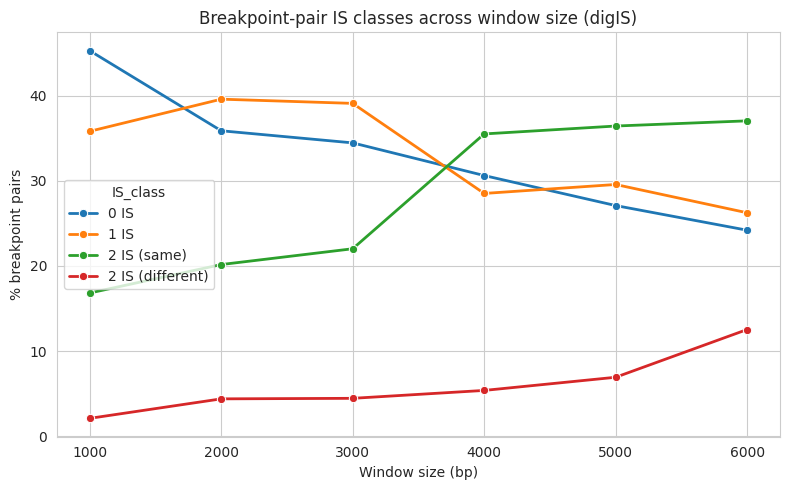

DONE.


In [27]:
#!/usr/bin/env python3

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
HWS = [500, 1000, 1500, 2000, 2500, 3000]

OUTDIR = os.path.join(BASE, "DIGIS_pairwise_summary")
os.makedirs(OUTDIR, exist_ok=True)

sns.set_style("whitegrid")

CLASS_ORDER = ["0 IS", "1 IS", "2 IS (same)", "2 IS (different)"]

# ============================================================
# HELPERS
# ============================================================

def parse_sid(s):
    d = {}
    for part in str(s).split("|"):
        if "=" in part:
            k, v = part.split("=", 1)
            d[k] = v
    return {
        "pair_id": int(d["pair"]),
        "bp_index": int(d["bp"]),
        "plasmid": d["plasmid"],
        "bp_kind": d["kind"],
        "breakpoint_pos_genome": int(d["pos"]),
        "window_hw_from_sid": int(d["hw"]),
    }

def normalize_is_name(x):
    if pd.isna(x):
        return None
    return str(x).strip()

def classify_pair(row):
    s = bool(row["start_has_is"])
    e = bool(row["end_has_is"])

    if (not s) and (not e):
        return "0 IS"
    if s ^ e:
        return "1 IS"
    if row["start_is_name_norm"] == row["end_is_name_norm"]:
        return "2 IS (same)"
    return "2 IS (different)"

def orientation_from_strand(row):
    if row["IS_class"] != "2 IS (same)":
        return None
    return "direct" if row["start_strand"] == row["end_strand"] else "inverted"

def load_digis_csv(csv_path):
    df = pd.read_csv(csv_path, sep=",")
    df.columns = [str(c).strip().replace("\ufeff", "") for c in df.columns]

    required = {"sid", "qid", "sstart", "send", "strand", "score", "evalue"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en {csv_path}: {missing}")

    meta = df["sid"].apply(parse_sid).apply(pd.Series)
    df = pd.concat([df, meta], axis=1)

    df["window_hw"] = df["window_hw_from_sid"].astype(int)
    df["window_size"] = 2 * df["window_hw"]
    df["breakpoint_pos_window"] = df["window_hw"] + 1

    df["sstart"] = pd.to_numeric(df["sstart"], errors="coerce")
    df["send"] = pd.to_numeric(df["send"], errors="coerce")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    df["evalue"] = pd.to_numeric(df["evalue"], errors="coerce")

    df = df.dropna(subset=["sstart", "send"]).copy()

    df["_start"] = df[["sstart", "send"]].min(axis=1)
    df["_end"] = df[["sstart", "send"]].max(axis=1)

    df["bp_inside"] = (
        (df["_start"] <= df["breakpoint_pos_window"]) &
        (df["_end"] >= df["breakpoint_pos_window"])
    )

    df["dist_to_bp"] = np.where(
        df["bp_inside"],
        0,
        np.minimum(
            np.abs(df["_start"] - df["breakpoint_pos_window"]),
            np.abs(df["_end"] - df["breakpoint_pos_window"])
        )
    )

    df["is_name_norm"] = df["qid"].apply(normalize_is_name)

    return df

def choose_best_hit_per_breakpoint(df):
    return (
        df.sort_values(
            ["pair_id", "bp_index", "bp_inside", "dist_to_bp", "score", "evalue"],
            ascending=[True, True, False, True, False, True]
        )
        .groupby(["pair_id", "bp_index"], as_index=False)
        .head(1)
        .copy()
    )

def load_pair_universe(master_tsv, hw):
    """
    Reconstruye el universo completo de pares a partir de breakpoints_master.tsv
    """
    master = pd.read_csv(master_tsv, sep="\t")

    start_base = (
        master[master["bp_kind"] == "start"]
        [["pair_id", "plasmid", "bp_index", "breakpoint_pos", "window_hw"]]
        .copy()
        .rename(columns={
            "bp_index": "bp_index_start",
            "breakpoint_pos": "bp_start_pos_genome"
        })
    )

    end_base = (
        master[master["bp_kind"] == "end"]
        [["pair_id", "plasmid", "bp_index", "breakpoint_pos", "window_hw"]]
        .copy()
        .rename(columns={
            "bp_index": "bp_index_end",
            "breakpoint_pos": "bp_end_pos_genome"
        })
    )

    pair_base = start_base.merge(
        end_base,
        on=["pair_id", "plasmid", "window_hw"],
        how="inner"
    )

    pair_base["window_size"] = 2 * hw
    return pair_base

# ============================================================
# MAIN
# ============================================================

all_raw_rows = []
all_best_rows = []
all_pair_rows = []
summary_rows = []

for hw in HWS:
    trace_dir = os.path.join(BASE, f"TRACEABLE_hardcut_95pid_{hw}_onebest_per_pair")

    csv_path = os.path.join(
        trace_dir,
        "digis_output",
        "results",
        "breakpoints_windows.csv"
    )

    master_tsv = os.path.join(trace_dir, "breakpoints_master.tsv")

    if not os.path.exists(master_tsv):
        print(f"[WARN] missing {master_tsv}")
        continue

    pair_base = load_pair_universe(master_tsv, hw)

    if not os.path.exists(csv_path):
        print(f"[WARN] missing {csv_path}; all pairs will be treated as 0 IS for HW={hw}")

        pair_df = pair_base.copy()
        pair_df["start_has_is"] = False
        pair_df["end_has_is"] = False
        pair_df["IS_class"] = "0 IS"
        pair_df["orientation"] = None

        pair_df.to_csv(
            os.path.join(OUTDIR, f"digis_pair_classification_hw{hw}.tsv"),
            sep="\t",
            index=False
        )

        summary_rows.append({
            "window_hw": hw,
            "window_size": 2 * hw,
            "n_raw_hits": 0,
            "n_breakpoints_with_hit": 0,
            "n_breakpoints_total": 2 * len(pair_base),
            "pct_breakpoints_with_hit": 0.0,
            "n_pairs": len(pair_df),
            "n_pairs_0IS": len(pair_df),
            "n_pairs_1IS": 0,
            "n_pairs_2IS_same": 0,
            "n_pairs_2IS_different": 0,
            "pct_pairs_0IS": 100.0,
            "pct_pairs_1IS": 0.0,
            "pct_pairs_2IS_same": 0.0,
            "pct_pairs_2IS_different": 0.0,
            "median_dist_detected_is": np.nan,
            "pct_detected_is_bp_inside": np.nan,
            "n_direct_same": 0,
            "n_inverted_same": 0,
        })

        all_pair_rows.append(pair_df)
        continue

    print(f"Parsing HW={hw}")
    raw_df = load_digis_csv(csv_path)
    best_df = choose_best_hit_per_breakpoint(raw_df)

    raw_df.to_csv(
        os.path.join(OUTDIR, f"digis_raw_hits_hw{hw}.tsv"),
        sep="\t",
        index=False
    )
    best_df.to_csv(
        os.path.join(OUTDIR, f"digis_best_hit_per_breakpoint_hw{hw}.tsv"),
        sep="\t",
        index=False
    )

    start_df = (
        best_df[best_df["bp_kind"] == "start"]
        .copy()
        .rename(columns={
            "bp_index": "bp_index_start",
            "qid": "start_is_name",
            "is_name_norm": "start_is_name_norm",
            "_start": "start_is_start_window",
            "_end": "start_is_end_window",
            "bp_inside": "start_bp_inside",
            "dist_to_bp": "start_dist_to_bp",
            "strand": "start_strand",
            "score": "start_score",
            "evalue": "start_evalue",
        })
    )

    end_df = (
        best_df[best_df["bp_kind"] == "end"]
        .copy()
        .rename(columns={
            "bp_index": "bp_index_end",
            "qid": "end_is_name",
            "is_name_norm": "end_is_name_norm",
            "_start": "end_is_start_window",
            "_end": "end_is_end_window",
            "bp_inside": "end_bp_inside",
            "dist_to_bp": "end_dist_to_bp",
            "strand": "end_strand",
            "score": "end_score",
            "evalue": "end_evalue",
        })
    )

    # mergear hits sobre el universo completo de pares
    pair_df = pair_base.merge(
        start_df[[
            "pair_id", "plasmid", "window_hw", "window_size", "bp_index_start",
            "start_is_name", "start_is_name_norm",
            "start_is_start_window", "start_is_end_window",
            "start_bp_inside", "start_dist_to_bp",
            "start_strand", "start_score", "start_evalue"
        ]],
        on=["pair_id", "plasmid", "window_hw", "window_size", "bp_index_start"],
        how="left"
    )

    pair_df = pair_df.merge(
        end_df[[
            "pair_id", "plasmid", "window_hw", "window_size", "bp_index_end",
            "end_is_name", "end_is_name_norm",
            "end_is_start_window", "end_is_end_window",
            "end_bp_inside", "end_dist_to_bp",
            "end_strand", "end_score", "end_evalue"
        ]],
        on=["pair_id", "plasmid", "window_hw", "window_size", "bp_index_end"],
        how="left"
    )

    pair_df["start_has_is"] = pair_df["start_is_name"].notna()
    pair_df["end_has_is"] = pair_df["end_is_name"].notna()

    pair_df["IS_class"] = pair_df.apply(classify_pair, axis=1)
    pair_df["orientation"] = pair_df.apply(orientation_from_strand, axis=1)

    pair_df.to_csv(
        os.path.join(OUTDIR, f"digis_pair_classification_hw{hw}.tsv"),
        sep="\t",
        index=False
    )

    n_pairs = len(pair_df)
    n_bp_total = 2 * n_pairs
    n_bp_with_hit = best_df["bp_index"].nunique()

    summary_rows.append({
        "window_hw": hw,
        "window_size": 2 * hw,
        "n_raw_hits": len(raw_df),
        "n_breakpoints_with_hit": n_bp_with_hit,
        "n_breakpoints_total": n_bp_total,
        "pct_breakpoints_with_hit": 100 * n_bp_with_hit / n_bp_total if n_bp_total else np.nan,
        "n_pairs": n_pairs,
        "n_pairs_0IS": int((pair_df["IS_class"] == "0 IS").sum()),
        "n_pairs_1IS": int((pair_df["IS_class"] == "1 IS").sum()),
        "n_pairs_2IS_same": int((pair_df["IS_class"] == "2 IS (same)").sum()),
        "n_pairs_2IS_different": int((pair_df["IS_class"] == "2 IS (different)").sum()),
        "pct_pairs_0IS": 100 * (pair_df["IS_class"] == "0 IS").mean(),
        "pct_pairs_1IS": 100 * (pair_df["IS_class"] == "1 IS").mean(),
        "pct_pairs_2IS_same": 100 * (pair_df["IS_class"] == "2 IS (same)").mean(),
        "pct_pairs_2IS_different": 100 * (pair_df["IS_class"] == "2 IS (different)").mean(),
        "median_dist_detected_is": float(best_df["dist_to_bp"].median()) if len(best_df) else np.nan,
        "pct_detected_is_bp_inside": 100 * best_df["bp_inside"].mean() if len(best_df) else np.nan,
        "n_direct_same": int((pair_df["orientation"] == "direct").sum()),
        "n_inverted_same": int((pair_df["orientation"] == "inverted").sum()),
    })

    all_raw_rows.append(raw_df)
    all_best_rows.append(best_df)
    all_pair_rows.append(pair_df)

# ============================================================
# SAVE TABLES
# ============================================================

all_pairs_df = pd.concat(all_pair_rows, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values("window_size")

if all_raw_rows:
    all_raw_df = pd.concat(all_raw_rows, ignore_index=True)
    all_raw_df.to_csv(os.path.join(OUTDIR, "all_digis_raw_hits.tsv"), sep="\t", index=False)

if all_best_rows:
    all_best_df = pd.concat(all_best_rows, ignore_index=True)
    all_best_df.to_csv(os.path.join(OUTDIR, "all_digis_best_hits.tsv"), sep="\t", index=False)

all_pairs_df.to_csv(os.path.join(OUTDIR, "all_digis_pair_classifications.tsv"), sep="\t", index=False)
summary_df.to_csv(os.path.join(OUTDIR, "summary_global.tsv"), sep="\t", index=False)

summary_classes_df = (
    all_pairs_df.groupby(["window_size", "window_hw", "IS_class"])
    .size()
    .reset_index(name="n_pairs")
)

all_window_sizes = (
    all_pairs_df[["window_size", "window_hw"]]
    .drop_duplicates()
    .sort_values("window_size")
    .reset_index(drop=True)
)

complete_index = (
    all_window_sizes.assign(key=1)
    .merge(pd.DataFrame({"IS_class": CLASS_ORDER, "key": 1}), on="key")
    .drop(columns="key")
)

summary_classes_complete = complete_index.merge(
    summary_classes_df,
    on=["window_size", "window_hw", "IS_class"],
    how="left"
)

summary_classes_complete["n_pairs"] = summary_classes_complete["n_pairs"].fillna(0).astype(int)
summary_classes_complete["pct_pairs"] = (
    100 * summary_classes_complete["n_pairs"] /
    summary_classes_complete.groupby("window_size")["n_pairs"].transform("sum")
)

summary_classes_complete.to_csv(
    os.path.join(OUTDIR, "summary_classes.tsv"),
    sep="\t",
    index=False
)

orientation_df = (
    all_pairs_df[all_pairs_df["IS_class"] == "2 IS (same)"]
    .groupby(["window_size", "window_hw", "orientation"])
    .size()
    .reset_index(name="n_pairs")
)

orientation_complete = (
    all_window_sizes.assign(key=1)
    .merge(pd.DataFrame({"orientation": ["direct", "inverted"], "key": 1}), on="key")
    .drop(columns="key")
    .merge(
        orientation_df,
        on=["window_size", "window_hw", "orientation"],
        how="left"
    )
)

orientation_complete["n_pairs"] = orientation_complete["n_pairs"].fillna(0).astype(int)
orientation_complete["pct_pairs"] = (
    100 * orientation_complete["n_pairs"] /
    orientation_complete.groupby("window_size")["n_pairs"].transform("sum")
)

orientation_complete.to_csv(
    os.path.join(OUTDIR, "summary_same_orientation.tsv"),
    sep="\t",
    index=False
)

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(8, 5))
plot_df = summary_classes_complete.copy()
plot_df["IS_class"] = pd.Categorical(plot_df["IS_class"], categories=CLASS_ORDER, ordered=True)
plot_df = plot_df.sort_values(["window_size", "IS_class"])

sns.lineplot(
    data=plot_df,
    x="window_size",
    y="pct_pairs",
    hue="IS_class",
    hue_order=CLASS_ORDER,
    marker="o",
    linewidth=2
)
plt.xlabel("Window size (bp)")
plt.ylabel("% breakpoint pairs")
plt.title("Breakpoint-pair IS classes across window size (digIS)")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "plot_pair_classes_lines.png"), dpi=300, bbox_inches="tight")
plt.show()

print("DONE.")

In [28]:
import pandas as pd

# ============================================================
# INPUT
# ============================================================

MERGED_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/real_vs_random_merged.tsv"

OUT_LONG = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/plot_dataset_long.tsv"
OUT_CATS = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/plot_dataset_categories.tsv"
OUT_WIDE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/plot_dataset_wide.tsv"

THRESHOLDS = [15, 450, 650]

# ============================================================
# HELPERS
# ============================================================

def categorize_length(x, thresholds):
    x = int(x)
    if x == 0:
        return "0"
    prev = 0
    for t in thresholds:
        if prev < x <= t:
            return f"{prev+1}–{t}"
        prev = t
    return f">{thresholds[-1]}"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(MERGED_TSV, sep="\t").copy()

df["best_length_real"] = pd.to_numeric(df["best_length_real"], errors="coerce").fillna(0).astype(int)
df["best_length_random"] = pd.to_numeric(df["best_length_random"], errors="coerce").fillna(0).astype(int)

# ============================================================
# 1. WIDE DATASET
# ============================================================

wide = df.copy()
wide["category_real"] = wide["best_length_real"].apply(lambda x: categorize_length(x, THRESHOLDS))
wide["category_random"] = wide["best_length_random"].apply(lambda x: categorize_length(x, THRESHOLDS))

wide.to_csv(OUT_WIDE, sep="\t", index=False)

# ============================================================
# 2. LONG / TIDY DATASET
# ============================================================

long = pd.concat([
    wide[[
        "pair_id", "plasmid", "plasmid_len",
        "bp_start_pos", "bp_end_pos",
        "random_start_pos", "random_end_pos",
        "best_length_real"
    ]].rename(columns={"best_length_real": "best_length"}).assign(condition="real"),

    wide[[
        "pair_id", "plasmid", "plasmid_len",
        "bp_start_pos", "bp_end_pos",
        "random_start_pos", "random_end_pos",
        "best_length_random"
    ]].rename(columns={"best_length_random": "best_length"}).assign(condition="random")
], ignore_index=True)

long["category"] = long["best_length"].apply(lambda x: categorize_length(x, THRESHOLDS))

# orden útil para R
cat_order = ["0", "1–15", "16–450", "451–650", ">650"]
long["category"] = pd.Categorical(long["category"], categories=cat_order, ordered=True)

long.to_csv(OUT_LONG, sep="\t", index=False)

# ============================================================
# 3. CATEGORY SUMMARY DATASET
# ============================================================

cats = (
    long.groupby(["condition", "category"], observed=False)
        .size()
        .reset_index(name="n_pairs")
)

totals = (
    long.groupby("condition")
        .size()
        .reset_index(name="total_pairs")
)

cats = cats.merge(totals, on="condition", how="left")
cats["fraction"] = cats["n_pairs"] / cats["total_pairs"]
cats["percentage"] = 100 * cats["fraction"]

cats.to_csv(OUT_CATS, sep="\t", index=False)

# ============================================================
# DONE
# ============================================================

print("Wrote:")
print(OUT_WIDE)
print(OUT_LONG)
print(OUT_CATS)

Wrote:
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/plot_dataset_wide.tsv
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/plot_dataset_long.tsv
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/plot_dataset_categories.tsv


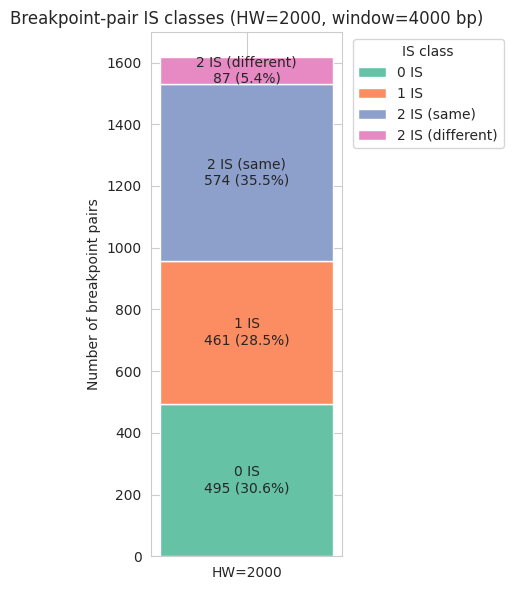

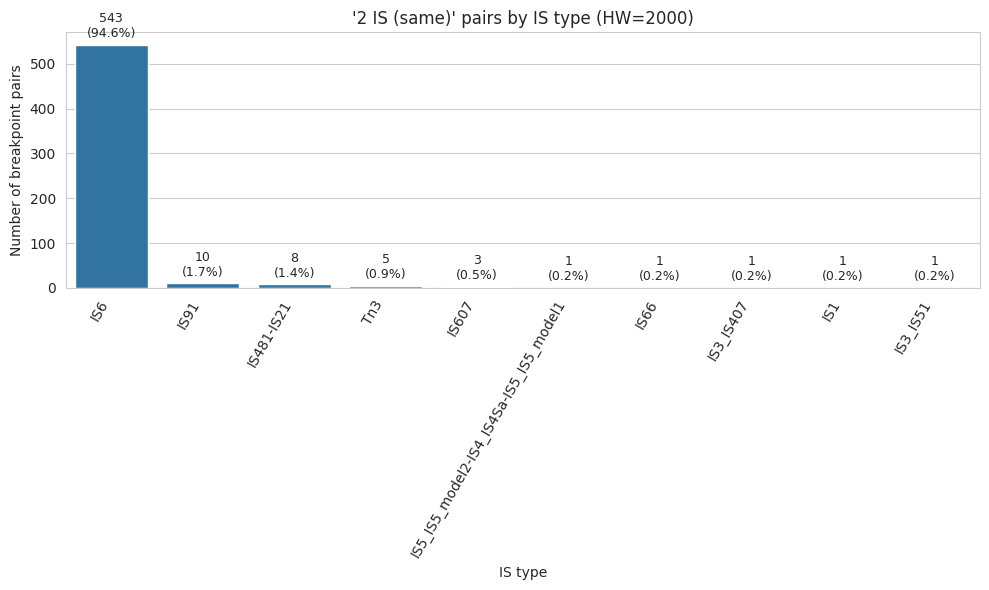

In [30]:
# ============================================================
# EXTRA PLOTS FOR A SINGLE WINDOW HW=2000
# ============================================================

TARGET_HW = 2000
TARGET_WS = 2 * TARGET_HW  # 4000 bp

# ------------------------------------------------------------
# 1. Stacked barplot de clases generales para HW=2000
# ------------------------------------------------------------
pair_2000 = all_pairs_df[all_pairs_df["window_hw"] == TARGET_HW].copy()

if pair_2000.empty:
    print(f"[WARN] No hay datos para HW={TARGET_HW}")
else:
    class_counts = (
        pair_2000["IS_class"]
        .value_counts()
        .reindex(CLASS_ORDER, fill_value=0)
        .reset_index()
    )
    class_counts.columns = ["IS_class", "n_pairs"]
    class_counts["pct_pairs"] = 100 * class_counts["n_pairs"] / class_counts["n_pairs"].sum()

    plt.figure(figsize=(4.5, 6))

    bottom = 0
    colors = sns.color_palette("Set2", n_colors=len(CLASS_ORDER))

    for i, (_, row) in enumerate(class_counts.iterrows()):
        plt.bar(
            x=["HW=2000"],
            height=[row["n_pairs"]],
            bottom=bottom,
            label=row["IS_class"],
            color=colors[i]
        )

        # texto dentro de cada segmento si no es demasiado pequeño
        if row["n_pairs"] > 0:
            y_center = bottom + row["n_pairs"] / 2
            plt.text(
                0,
                y_center,
                f'{row["IS_class"]}\n{row["n_pairs"]} ({row["pct_pairs"]:.1f}%)',
                ha="center",
                va="center",
                fontsize=10
            )

        bottom += row["n_pairs"]

    plt.ylabel("Number of breakpoint pairs")
    plt.xlabel("")
    plt.title(f"Breakpoint-pair IS classes (HW={TARGET_HW}, window={TARGET_WS} bp)")
    plt.legend(title="IS class", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTDIR, f"stacked_barplot_pair_classes_hw{TARGET_HW}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    # ------------------------------------------------------------
    # 2. Dentro de 2 IS (same): barplot por tipo de IS
    # ------------------------------------------------------------
    same_2000 = pair_2000[pair_2000["IS_class"] == "2 IS (same)"].copy()

    if same_2000.empty:
        print(f"[WARN] No hay pares '2 IS (same)' para HW={TARGET_HW}")
    else:
        same_type_counts = (
            same_2000["start_is_name_norm"]
            .fillna("UNKNOWN")
            .value_counts()
            .reset_index()
        )
        same_type_counts.columns = ["IS_type", "n_pairs"]
        same_type_counts["pct_pairs"] = 100 * same_type_counts["n_pairs"] / same_type_counts["n_pairs"].sum()

        plt.figure(figsize=(10, 6))
        ax = sns.barplot(
            data=same_type_counts,
            x="IS_type",
            y="n_pairs"
        )

        for i, row in same_type_counts.iterrows():
            ax.text(
                i,
                row["n_pairs"] + max(same_type_counts["n_pairs"]) * 0.02,
                f'{row["n_pairs"]}\n({row["pct_pairs"]:.1f}%)',
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.xlabel("IS type")
        plt.ylabel("Number of breakpoint pairs")
        plt.title(f"'2 IS (same)' pairs by IS type (HW={TARGET_HW})")
        plt.xticks(rotation=60, ha="right")
        plt.tight_layout()
        plt.savefig(
            os.path.join(OUTDIR, f"barplot_2ISsame_types_hw{TARGET_HW}.png"),
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

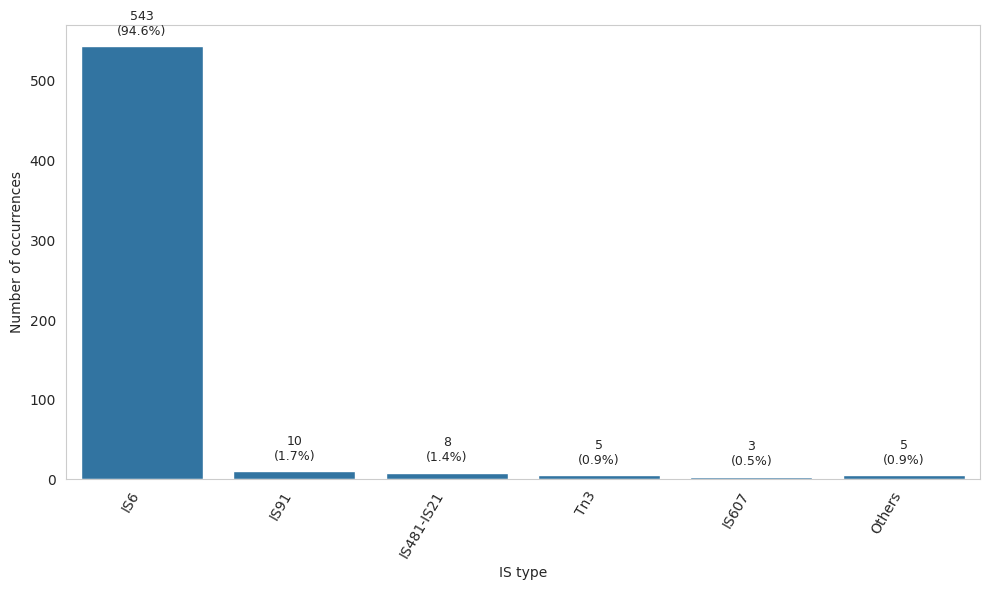

[OK] SVG saved to: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/for_R/barplot_2ISsame_types_hw2000_grouped_others.svg


In [41]:
# ------------------------------------------------------------
# 2. Dentro de 2 IS (same): barplot por tipo de IS
#    Agrupar IS con 1 ocurrencia como "Others"
# ------------------------------------------------------------
same_2000 = pair_2000[pair_2000["IS_class"] == "2 IS (same)"].copy()

if same_2000.empty:
    print(f"[WARN] No hay pares '2 IS (same)' para HW={TARGET_HW}")
else:
    same_2000["IS_type_grouped"] = (
        same_2000["start_is_name_norm"]
        .fillna("UNKNOWN")
    )

    counts_raw = same_2000["IS_type_grouped"].value_counts()

    rare_types = counts_raw[counts_raw == 1].index

    same_2000["IS_type_grouped"] = same_2000["IS_type_grouped"].where(
        ~same_2000["IS_type_grouped"].isin(rare_types),
        "Others"
    )

    same_type_counts = (
        same_2000["IS_type_grouped"]
        .value_counts()
        .reset_index()
    )

    same_type_counts.columns = ["IS_type", "n_pairs"]

    same_type_counts["pct_pairs"] = (
        100 * same_type_counts["n_pairs"] / same_type_counts["n_pairs"].sum()
    )

    # poner Others al final
    same_type_counts["sort_key"] = same_type_counts["IS_type"].eq("Others")
    same_type_counts = (
        same_type_counts
        .sort_values(["sort_key", "n_pairs"], ascending=[True, False])
        .drop(columns="sort_key")
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=same_type_counts,
        x="IS_type",
        y="n_pairs"
    )

    for i, row in same_type_counts.iterrows():
        ax.text(
            i,
            row["n_pairs"] + max(same_type_counts["n_pairs"]) * 0.02,
            f'{row["n_pairs"]}\n({row["pct_pairs"]:.1f}%)',
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.grid(False)
    ax.set_title("")
    ax.set_xlabel("IS type")
    ax.set_ylabel("Number of occurrences")

    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()

    out_svg = os.path.join(
        OUTDIR,
        f"barplot_2ISsame_types_hw{TARGET_HW}_grouped_others.svg"
    )

    plt.savefig(out_svg, format="svg", bbox_inches="tight")
    plt.show()

    print(f"[OK] SVG saved to: {out_svg}")

  relative_orientation  n_pairs  pct_pairs
0           convergent      448  78.048780
1            divergent       22   3.832753
2       same_direction      104  18.118467
3              unknown        0   0.000000


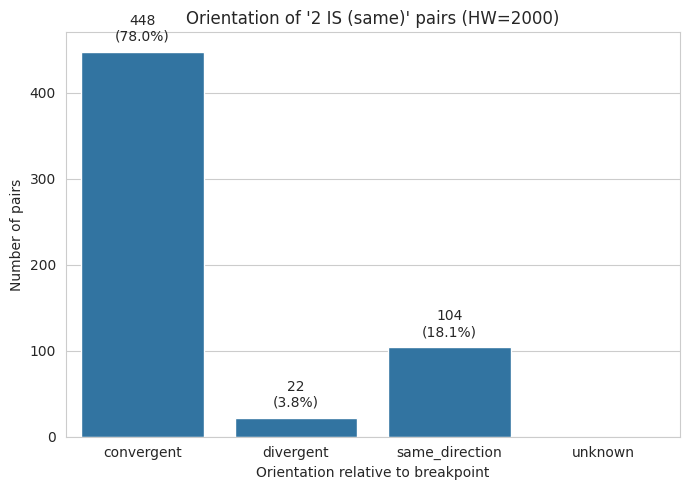

In [32]:
# ============================================================
# ORIENTACIÓN DE 2 IS (same) PARA HW=2000
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_HW = 2000

same_2000 = all_pairs_df[
    (all_pairs_df["window_hw"] == TARGET_HW) &
    (all_pairs_df["IS_class"] == "2 IS (same)")
].copy()

if same_2000.empty:
    print(f"[WARN] No hay pares '2 IS (same)' para HW={TARGET_HW}")
else:
    def points_toward_breakpoint(hit_start, hit_end, strand, bp_pos):
        """
        True  -> la IS apunta hacia el breakpoint
        False -> la IS apunta alejándose del breakpoint
        NaN   -> no se puede decidir
        """
        if pd.isna(hit_start) or pd.isna(hit_end) or pd.isna(strand):
            return np.nan

        hit_center = (float(hit_start) + float(hit_end)) / 2.0

        # breakpoint a la derecha del hit
        if hit_center < bp_pos:
            return True if strand == "+" else False

        # breakpoint a la izquierda del hit
        elif hit_center > bp_pos:
            return True if strand == "-" else False

        # caso raro: el breakpoint cae justo en el centro
        else:
            return np.nan

    def classify_orientation(row):
        s = row["start_points_toward_bp"]
        e = row["end_points_toward_bp"]

        if pd.isna(s) or pd.isna(e):
            return "unknown"

        if s and e:
            return "convergent"
        elif (not s) and (not e):
            return "divergent"
        else:
            return "same_direction"

    # En cada ventana, el breakpoint está en el centro: hw + 1
    bp_pos = TARGET_HW + 1

    same_2000["start_points_toward_bp"] = same_2000.apply(
        lambda r: points_toward_breakpoint(
            r["start_is_start_window"],
            r["start_is_end_window"],
            r["start_strand"],
            bp_pos
        ),
        axis=1
    )

    same_2000["end_points_toward_bp"] = same_2000.apply(
        lambda r: points_toward_breakpoint(
            r["end_is_start_window"],
            r["end_is_end_window"],
            r["end_strand"],
            bp_pos
        ),
        axis=1
    )

    same_2000["relative_orientation"] = same_2000.apply(classify_orientation, axis=1)

    # tabla resumen
    ori_counts = (
        same_2000["relative_orientation"]
        .value_counts()
        .reindex(["convergent", "divergent", "same_direction", "unknown"], fill_value=0)
        .reset_index()
    )
    ori_counts.columns = ["relative_orientation", "n_pairs"]
    ori_counts["pct_pairs"] = 100 * ori_counts["n_pairs"] / ori_counts["n_pairs"].sum()

    print(ori_counts)

    # guardar tabla detallada
    same_2000.to_csv(
        os.path.join(OUTDIR, f"pairs_2ISsame_orientation_hw{TARGET_HW}.tsv"),
        sep="\t",
        index=False
    )

    # plot
    plt.figure(figsize=(7, 5))
    ax = sns.barplot(
        data=ori_counts,
        x="relative_orientation",
        y="n_pairs",
        order=["convergent", "divergent", "same_direction", "unknown"]
    )

    ymax = max(ori_counts["n_pairs"].max(), 1)
    for i, row in ori_counts.iterrows():
        if row["n_pairs"] > 0:
            ax.text(
                i,
                row["n_pairs"] + ymax * 0.02,
                f'{row["n_pairs"]}\n({row["pct_pairs"]:.1f}%)',
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.xlabel("Orientation relative to breakpoint")
    plt.ylabel("Number of pairs")
    plt.title(f"Orientation of '2 IS (same)' pairs (HW={TARGET_HW})")
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTDIR, f"barplot_2ISsame_orientation_hw{TARGET_HW}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## control ## 


In [34]:
#!/usr/bin/env python3

import os
import subprocess
import random
import pandas as pd

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
PLASMID_FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"
SAMTOOLS = "/home/nacho/mambaforge/envs/samtools/bin/samtools"

WINDOW_HW = 2000
RANDOM_SEED = 12345

REAL_DIR = os.path.join(BASE_DIR, f"TRACEABLE_hardcut_95pid_{WINDOW_HW}_onebest_per_pair")
MASTER_TSV = os.path.join(REAL_DIR, "breakpoints_master.tsv")

CONTROL_DIR = os.path.join(REAL_DIR, "random_control_two_random_points_hw2000")
WINDOWS_DIR = os.path.join(CONTROL_DIR, "windows")

RANDOM_MASTER_TSV = os.path.join(CONTROL_DIR, "random_windows_master.tsv")
RANDOM_FASTA = os.path.join(CONTROL_DIR, "random_windows.fa")

os.makedirs(CONTROL_DIR, exist_ok=True)
os.makedirs(WINDOWS_DIR, exist_ok=True)

rng = random.Random(RANDOM_SEED)

# ============================================================
# HELPERS
# ============================================================

def get_fasta_path(chrom):
    for fname in os.listdir(PLASMID_FASTA_DIR):
        if fname.endswith((".fna", ".fa", ".fasta")) and fname.startswith(chrom):
            return os.path.join(PLASMID_FASTA_DIR, fname)
    return None

def normalize_circular_pos(pos, L):
    return ((int(pos) - 1) % int(L)) + 1

def circular_window(center, L, hw):
    """
    Devuelve una o dos regiones 1-based cerradas válidas
    para una ventana circular centrada en 'center' con semiventana 'hw'.
    """
    L = int(L)
    hw = int(hw)
    center = normalize_circular_pos(center, L)

    start = center - hw
    end = center + hw

    if start >= 1 and end <= L:
        return [(start, end)]

    parts = []

    if start < 1:
        left_start = L + start + 1
        left_end = L
        right_start = 1
        right_end = end

        if 1 <= left_start <= left_end <= L:
            parts.append((left_start, left_end))
        if 1 <= right_start <= right_end <= L:
            parts.append((right_start, right_end))
        return parts if parts else None

    if end > L:
        left_start = start
        left_end = L
        right_start = 1
        right_end = end - L

        if 1 <= left_start <= left_end <= L:
            parts.append((left_start, left_end))
        if 1 <= right_start <= right_end <= L:
            parts.append((right_start, right_end))
        return parts if parts else None

    return None

def fetch_sequence(fasta, chrom, parts):
    seq = []
    for s, e in parts:
        region = f"{chrom}:{int(s)}-{int(e)}"
        out = subprocess.check_output([SAMTOOLS, "faidx", fasta, region]).decode()
        seq.append("".join(out.split("\n")[1:]))
    return "".join(seq)

# ============================================================
# LOAD REAL PAIRS
# ============================================================

print("[1/3] Loading real breakpoint pairs...")

master = pd.read_csv(MASTER_TSV, sep="\t")

m_start = (
    master[master["bp_kind"] == "start"]
    [["pair_id", "plasmid", "breakpoint_pos", "plasmid_len"]]
    .rename(columns={"breakpoint_pos": "bp_start_pos"})
)

m_end = (
    master[master["bp_kind"] == "end"]
    [["pair_id", "plasmid", "breakpoint_pos", "plasmid_len"]]
    .rename(columns={"breakpoint_pos": "bp_end_pos"})
)

pairs = m_start.merge(
    m_end,
    on=["pair_id", "plasmid", "plasmid_len"],
    how="inner"
).copy()

pairs["fasta_plasmid"] = pairs["plasmid"].apply(get_fasta_path)

if pairs["fasta_plasmid"].isna().any():
    missing = pairs.loc[pairs["fasta_plasmid"].isna(), "plasmid"].unique().tolist()
    raise FileNotFoundError(f"No FASTA found for plasmids: {missing[:10]}")

print(f"Loaded pairs: {len(pairs)}")

# ============================================================
# GENERATE RANDOM WINDOWS
# ============================================================

print("[2/3] Generating random windows...")

rows = []
fasta_entries = []

for _, r in pairs.iterrows():
    pair_id = int(r["pair_id"])
    plasmid = r["plasmid"]
    L = int(r["plasmid_len"])
    fasta = r["fasta_plasmid"]

    # dos posiciones aleatorias sin restricciones
    rand_start = rng.randint(1, L)
    rand_end = rng.randint(1, L)

    for kind, pos in [("start", rand_start), ("end", rand_end)]:
        parts = circular_window(pos, L, WINDOW_HW)

        if not parts:
            print(f"[WARN] no valid window for pair_id={pair_id}, kind={kind}, pos={pos}, L={L}")
            continue

        try:
            seq = fetch_sequence(fasta, plasmid, parts)
        except Exception as ex:
            print(f"[WARN] failed extracting random window for pair_id={pair_id}, kind={kind}, pos={pos}, L={L}: {ex}")
            continue

        header = f"pair={pair_id}|plasmid={plasmid}|kind={kind}|pos={pos}|hw={WINDOW_HW}"
        fa_path = os.path.join(WINDOWS_DIR, f"pair_{pair_id:05d}_{kind}.fa")

        with open(fa_path, "w") as out:
            out.write(f">{header}\n{seq}\n")

        fasta_entries.append(f">{header}\n{seq}\n")

        rows.append({
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_kind": kind,
            "random_center": pos,
            "plasmid_len": L,
            "fasta_header": header,
            "fasta_path": fa_path,
        })

random_master = pd.DataFrame(rows)
random_master.to_csv(RANDOM_MASTER_TSV, sep="\t", index=False)

with open(RANDOM_FASTA, "w") as out:
    for x in fasta_entries:
        out.write(x)

print(f"Wrote: {RANDOM_MASTER_TSV}")
print(f"Wrote: {RANDOM_FASTA}")
print(f"Random windows generated: {len(random_master)}")
print("[3/3] DONE.")
print(f"Control dir: {CONTROL_DIR}")

[1/3] Loading real breakpoint pairs...
Loaded pairs: 1617
[2/3] Generating random windows...
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/random_windows_master.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/random_windows.fa
Random windows generated: 3234
[3/3] DONE.
Control dir: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000


[1/5] Looking for digIS CSV...
Using digIS CSV: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/digis_output/results/random_windows.csv
[2/5] Loading inputs...
digIS raw hits: 1792
[3/5] Choosing best hit per random breakpoint...
Best breakpoint hits retained: 1184
[4/5] Building pair table...
[5/5] Writing summary...
 window_hw  window_size  n_pairs  n_pairs_0IS  n_pairs_1IS  n_pairs_2IS_same  n_pairs_2IS_different  pct_pairs_0IS  pct_pairs_1IS  pct_pairs_2IS_same  pct_pairs_2IS_different  median_dist_detected_is  pct_detected_is_bp_inside
      2000         4000     1617          721          608                85                    203      44.588745      37.600495            5.256648                12.554113                    231.0                  38.597973


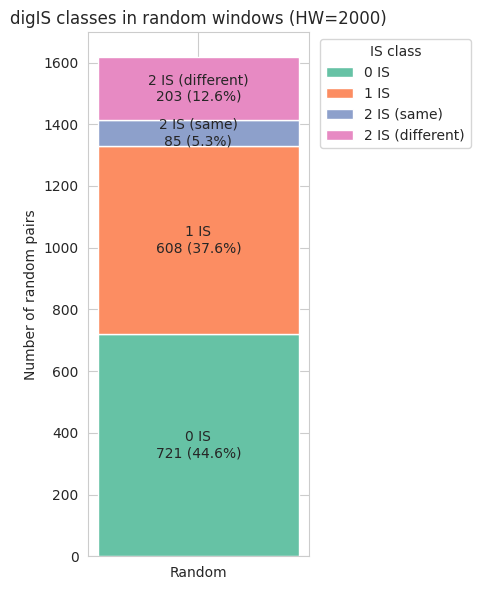

Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/digis_random_pair_classification.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/digis_random_summary.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/digis_random_class_barplot_hw2000.png
DONE.


In [36]:
#!/usr/bin/env python3

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

WINDOW_HW = 2000
CLASS_ORDER = ["0 IS", "1 IS", "2 IS (same)", "2 IS (different)"]

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
REAL_DIR = os.path.join(BASE_DIR, f"TRACEABLE_hardcut_95pid_{WINDOW_HW}_onebest_per_pair")
CONTROL_DIR = os.path.join(REAL_DIR, "random_control_two_random_points_hw2000")

RANDOM_MASTER_TSV = os.path.join(CONTROL_DIR, "random_windows_master.tsv")
DIGIS_RESULTS_DIR = os.path.join(CONTROL_DIR, "digis_output", "results")

OUT_PAIR_TSV = os.path.join(CONTROL_DIR, "digis_random_pair_classification.tsv")
OUT_SUMMARY_TSV = os.path.join(CONTROL_DIR, "digis_random_summary.tsv")
OUT_BARPLOT = os.path.join(CONTROL_DIR, "digis_random_class_barplot_hw2000.png")

# ============================================================
# HELPERS
# ============================================================

def parse_sid(s):
    d = {}
    for part in str(s).split("|"):
        if "=" in part:
            k, v = part.split("=", 1)
            d[k] = v
    return {
        "pair_id": int(d["pair"]),
        "plasmid": d["plasmid"],
        "bp_kind": d["kind"],
        "random_center": int(d["pos"]),
        "window_hw": int(d["hw"]),
    }

def normalize_is_name(x):
    if pd.isna(x):
        return None
    return str(x).strip()

def classify_pair(row):
    s = bool(row["start_has_is"])
    e = bool(row["end_has_is"])

    if (not s) and (not e):
        return "0 IS"
    if s ^ e:
        return "1 IS"
    if row["start_is_name_norm"] == row["end_is_name_norm"]:
        return "2 IS (same)"
    return "2 IS (different)"

def choose_best_hit_per_breakpoint(df):
    return (
        df.sort_values(
            ["pair_id", "bp_kind", "bp_inside", "dist_to_bp", "score", "evalue"],
            ascending=[True, True, False, True, False, True]
        )
        .groupby(["pair_id", "bp_kind"], as_index=False)
        .head(1)
        .copy()
    )

# ============================================================
# 1. LOCATE digIS CSV
# ============================================================

print("[1/5] Looking for digIS CSV...")

csv_candidates = sorted(
    [
        os.path.join(DIGIS_RESULTS_DIR, x)
        for x in os.listdir(DIGIS_RESULTS_DIR)
        if x.endswith(".csv")
    ]
)

if len(csv_candidates) == 0:
    raise FileNotFoundError(f"No CSV files found in: {DIGIS_RESULTS_DIR}")

# normalmente habrá uno, pero si hay varios cogemos el primero
DIGIS_CSV = csv_candidates[0]
print(f"Using digIS CSV: {DIGIS_CSV}")

# ============================================================
# 2. LOAD INPUTS
# ============================================================

print("[2/5] Loading inputs...")

random_master = pd.read_csv(RANDOM_MASTER_TSV, sep="\t")

df = pd.read_csv(DIGIS_CSV, sep=",")
df.columns = [str(c).strip().replace("\ufeff", "") for c in df.columns]

required = {"sid", "qid", "sstart", "send", "strand", "score", "evalue"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in digIS CSV: {missing}")

meta = df["sid"].apply(parse_sid).apply(pd.Series)
df = pd.concat([df, meta], axis=1)

df["window_size"] = 2 * df["window_hw"]
df["breakpoint_pos_window"] = df["window_hw"] + 1

df["sstart"] = pd.to_numeric(df["sstart"], errors="coerce")
df["send"] = pd.to_numeric(df["send"], errors="coerce")
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["evalue"] = pd.to_numeric(df["evalue"], errors="coerce")

df = df.dropna(subset=["sstart", "send"]).copy()

df["_start"] = df[["sstart", "send"]].min(axis=1)
df["_end"] = df[["sstart", "send"]].max(axis=1)

df["bp_inside"] = (
    (df["_start"] <= df["breakpoint_pos_window"]) &
    (df["_end"] >= df["breakpoint_pos_window"])
)

df["dist_to_bp"] = np.where(
    df["bp_inside"],
    0,
    np.minimum(
        np.abs(df["_start"] - df["breakpoint_pos_window"]),
        np.abs(df["_end"] - df["breakpoint_pos_window"])
    )
)

df["is_name_norm"] = df["qid"].apply(normalize_is_name)

print(f"digIS raw hits: {len(df)}")

# ============================================================
# 3. CHOOSE BEST HIT PER RANDOM BREAKPOINT
# ============================================================

print("[3/5] Choosing best hit per random breakpoint...")

best_df = choose_best_hit_per_breakpoint(df)

print(f"Best breakpoint hits retained: {len(best_df)}")

start_df = (
    best_df[best_df["bp_kind"] == "start"]
    .copy()
    .rename(columns={
        "qid": "start_is_name",
        "is_name_norm": "start_is_name_norm",
        "_start": "start_is_start_window",
        "_end": "start_is_end_window",
        "bp_inside": "start_bp_inside",
        "dist_to_bp": "start_dist_to_bp",
        "strand": "start_strand",
        "score": "start_score",
        "evalue": "start_evalue",
    })
)

end_df = (
    best_df[best_df["bp_kind"] == "end"]
    .copy()
    .rename(columns={
        "qid": "end_is_name",
        "is_name_norm": "end_is_name_norm",
        "_start": "end_is_start_window",
        "_end": "end_is_end_window",
        "bp_inside": "end_bp_inside",
        "dist_to_bp": "end_dist_to_bp",
        "strand": "end_strand",
        "score": "end_score",
        "evalue": "end_evalue",
    })
)

# ============================================================
# 4. BUILD PAIR TABLE
# ============================================================

print("[4/5] Building pair table...")

pair_base = (
    random_master.pivot_table(
        index=["pair_id", "plasmid"],
        columns="bp_kind",
        values="random_center",
        aggfunc="first"
    )
    .reset_index()
    .rename(columns={"start": "random_start_pos", "end": "random_end_pos"})
)

pair_df = pair_base.merge(
    start_df[[
        "pair_id", "plasmid",
        "start_is_name", "start_is_name_norm",
        "start_is_start_window", "start_is_end_window",
        "start_bp_inside", "start_dist_to_bp",
        "start_strand", "start_score", "start_evalue"
    ]],
    on=["pair_id", "plasmid"],
    how="left"
)

pair_df = pair_df.merge(
    end_df[[
        "pair_id", "plasmid",
        "end_is_name", "end_is_name_norm",
        "end_is_start_window", "end_is_end_window",
        "end_bp_inside", "end_dist_to_bp",
        "end_strand", "end_score", "end_evalue"
    ]],
    on=["pair_id", "plasmid"],
    how="left"
)

pair_df["start_has_is"] = pair_df["start_is_name"].notna()
pair_df["end_has_is"] = pair_df["end_is_name"].notna()
pair_df["IS_class"] = pair_df.apply(classify_pair, axis=1)

pair_df.to_csv(OUT_PAIR_TSV, sep="\t", index=False)

# ============================================================
# 5. SUMMARY + STACKED BARPLOT
# ============================================================

print("[5/5] Writing summary...")

summary = pd.DataFrame([{
    "window_hw": WINDOW_HW,
    "window_size": 2 * WINDOW_HW,
    "n_pairs": len(pair_df),
    "n_pairs_0IS": int((pair_df["IS_class"] == "0 IS").sum()),
    "n_pairs_1IS": int((pair_df["IS_class"] == "1 IS").sum()),
    "n_pairs_2IS_same": int((pair_df["IS_class"] == "2 IS (same)").sum()),
    "n_pairs_2IS_different": int((pair_df["IS_class"] == "2 IS (different)").sum()),
    "pct_pairs_0IS": 100 * (pair_df["IS_class"] == "0 IS").mean(),
    "pct_pairs_1IS": 100 * (pair_df["IS_class"] == "1 IS").mean(),
    "pct_pairs_2IS_same": 100 * (pair_df["IS_class"] == "2 IS (same)").mean(),
    "pct_pairs_2IS_different": 100 * (pair_df["IS_class"] == "2 IS (different)").mean(),
    "median_dist_detected_is": float(best_df["dist_to_bp"].median()) if len(best_df) else np.nan,
    "pct_detected_is_bp_inside": 100 * best_df["bp_inside"].mean() if len(best_df) else np.nan,
}])

summary.to_csv(OUT_SUMMARY_TSV, sep="\t", index=False)

print(summary.to_string(index=False))

# ------------------------------------------------------------
# stacked barplot
# ------------------------------------------------------------
plot_df = (
    pair_df["IS_class"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
    .reset_index()
)
plot_df.columns = ["IS_class", "n_pairs"]
plot_df["pct_pairs"] = 100 * plot_df["n_pairs"] / plot_df["n_pairs"].sum()

sns.set_style("whitegrid")
plt.figure(figsize=(4.8, 6))

bottom = 0
colors = sns.color_palette("Set2", n_colors=len(CLASS_ORDER))

for i, (_, row) in enumerate(plot_df.iterrows()):
    plt.bar(
        x=["Random"],
        height=[row["n_pairs"]],
        bottom=bottom,
        label=row["IS_class"],
        color=colors[i]
    )

    if row["n_pairs"] > 0:
        y_center = bottom + row["n_pairs"] / 2
        plt.text(
            0,
            y_center,
            f'{row["IS_class"]}\n{row["n_pairs"]} ({row["pct_pairs"]:.1f}%)',
            ha="center",
            va="center",
            fontsize=10
        )

    bottom += row["n_pairs"]

plt.xlabel("")
plt.ylabel("Number of random pairs")
plt.title(f"digIS classes in random windows (HW={WINDOW_HW})")
plt.legend(title="IS class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_BARPLOT, dpi=300, bbox_inches="tight")
plt.show()

print(f"Wrote: {OUT_PAIR_TSV}")
print(f"Wrote: {OUT_SUMMARY_TSV}")
print(f"Wrote: {OUT_BARPLOT}")
print("DONE.")

In [38]:
import os
import pandas as pd

# ============================================================
# CONFIG
# ============================================================

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
HW = 2000

REAL_DIR = os.path.join(BASE, "DIGIS_pairwise_summary")
CONTROL_DIR = os.path.join(
    BASE,
    f"TRACEABLE_hardcut_95pid_{HW}_onebest_per_pair",
    "random_control_two_random_points_hw2000"
)

REAL_PAIR_TSV = os.path.join(REAL_DIR, f"digis_pair_classification_hw{HW}.tsv")
REAL_ORI_TSV = os.path.join(REAL_DIR, f"pairs_2ISsame_orientation_hw{HW}.tsv")
CONTROL_MASTER_TSV = os.path.join(CONTROL_DIR, "random_windows_master.tsv")

OUTDIR = os.path.join(CONTROL_DIR, "for_R")
os.makedirs(OUTDIR, exist_ok=True)

OUT_CLASS_LONG = os.path.join(OUTDIR, "pair_classes_real_vs_control_long.tsv")
OUT_CLASS_SUMMARY = os.path.join(OUTDIR, "pair_classes_real_vs_control_summary.tsv")
OUT_ORI_LONG = os.path.join(OUTDIR, "orientation_real_vs_control_long.tsv")
OUT_ORI_SUMMARY = os.path.join(OUTDIR, "orientation_real_vs_control_summary.tsv")

CLASS_ORDER = ["0 IS", "1 IS", "2 IS (same)", "2 IS (different)"]
ORI_ORDER = ["repeat", "inverted"]

# ============================================================
# HELPERS
# ============================================================

def classify_pair(row):
    s = bool(row["start_has_is"])
    e = bool(row["end_has_is"])

    if (not s) and (not e):
        return "0 IS"
    if s ^ e:
        return "1 IS"
    if row["start_is_name_norm"] == row["end_is_name_norm"]:
        return "2 IS (same)"
    return "2 IS (different)"

def parse_sid(s):
    d = {}
    for part in str(s).split("|"):
        if "=" in part:
            k, v = part.split("=", 1)
            d[k] = v
    return {
        "pair_id": int(d["pair"]),
        "plasmid": d["plasmid"],
        "bp_kind": d["kind"],
        "window_hw": int(d["hw"]),
    }

# ============================================================
# 1. REAL: pair classes
# ============================================================

real_pair = pd.read_csv(REAL_PAIR_TSV, sep="\t").copy()
real_pair["dataset"] = "Breakpoints"

real_class_long = real_pair[["pair_id", "plasmid", "IS_class", "dataset"]].copy()

# ============================================================
# 2. CONTROL: reconstruct pair classes from digIS output
# ============================================================

control_csv = os.path.join(
    CONTROL_DIR,
    "digis_output",
    "results",
    "random_windows.csv"
)

if not os.path.exists(control_csv):
    raise FileNotFoundError(
        f"No encuentro {control_csv}. "
        "Primero corre digIS sobre random_windows.fa"
    )

control_hits = pd.read_csv(control_csv, sep=",").copy()
meta = control_hits["sid"].apply(parse_sid).apply(pd.Series)
control_hits = pd.concat([control_hits, meta], axis=1)

control_hits["sstart"] = pd.to_numeric(control_hits["sstart"], errors="coerce")
control_hits["send"] = pd.to_numeric(control_hits["send"], errors="coerce")
control_hits["score"] = pd.to_numeric(control_hits["score"], errors="coerce")
control_hits["evalue"] = pd.to_numeric(control_hits["evalue"], errors="coerce")

control_hits["_start"] = control_hits[["sstart", "send"]].min(axis=1)
control_hits["_end"] = control_hits[["sstart", "send"]].max(axis=1)
control_hits["bp_pos"] = control_hits["window_hw"] + 1

control_hits["bp_inside"] = (
    (control_hits["_start"] <= control_hits["bp_pos"]) &
    (control_hits["_end"] >= control_hits["bp_pos"])
)

control_hits["dist_to_bp"] = (
    (control_hits["_start"] - control_hits["bp_pos"]).abs()
    .combine((control_hits["_end"] - control_hits["bp_pos"]).abs(), min)
)

control_hits["dist_to_bp"] = control_hits["dist_to_bp"].where(~control_hits["bp_inside"], 0)
control_hits["is_name_norm"] = control_hits["qid"].astype(str).str.strip()

control_best = (
    control_hits.sort_values(
        ["pair_id", "bp_kind", "bp_inside", "dist_to_bp", "score", "evalue"],
        ascending=[True, True, False, True, False, True]
    )
    .groupby(["pair_id", "bp_kind"], as_index=False)
    .head(1)
    .copy()
)

control_master = pd.read_csv(CONTROL_MASTER_TSV, sep="\t").copy()

start_base = (
    control_master[control_master["bp_kind"] == "start"]
    [["pair_id", "plasmid"]]
    .drop_duplicates()
)

end_base = (
    control_master[control_master["bp_kind"] == "end"]
    [["pair_id", "plasmid"]]
    .drop_duplicates()
)

control_pair_base = start_base.merge(end_base, on=["pair_id", "plasmid"], how="inner")

start_df = (
    control_best[control_best["bp_kind"] == "start"]
    [["pair_id", "plasmid", "qid", "is_name_norm"]]
    .rename(columns={
        "qid": "start_is_name",
        "is_name_norm": "start_is_name_norm"
    })
)

end_df = (
    control_best[control_best["bp_kind"] == "end"]
    [["pair_id", "plasmid", "qid", "is_name_norm"]]
    .rename(columns={
        "qid": "end_is_name",
        "is_name_norm": "end_is_name_norm"
    })
)

control_pair = control_pair_base.merge(
    start_df, on=["pair_id", "plasmid"], how="left"
).merge(
    end_df, on=["pair_id", "plasmid"], how="left"
)

control_pair["start_has_is"] = control_pair["start_is_name"].notna()
control_pair["end_has_is"] = control_pair["end_is_name"].notna()
control_pair["IS_class"] = control_pair.apply(classify_pair, axis=1)
control_pair["dataset"] = "Random"

control_class_long = control_pair[["pair_id", "plasmid", "IS_class", "dataset"]].copy()

# ============================================================
# 3. MERGE CLASSES
# ============================================================

class_long = pd.concat([real_class_long, control_class_long], ignore_index=True)
class_long["IS_class"] = pd.Categorical(class_long["IS_class"], categories=CLASS_ORDER, ordered=True)
class_long.to_csv(OUT_CLASS_LONG, sep="\t", index=False)

class_summary = (
    class_long.groupby(["dataset", "IS_class"], observed=False)
    .size()
    .reset_index(name="n_pairs")
)

totals = (
    class_long.groupby("dataset")
    .size()
    .reset_index(name="total_pairs")
)

class_summary = class_summary.merge(totals, on="dataset", how="left")
class_summary["fraction"] = class_summary["n_pairs"] / class_summary["total_pairs"]
class_summary["percentage"] = 100 * class_summary["fraction"]
class_summary.to_csv(OUT_CLASS_SUMMARY, sep="\t", index=False)

# ============================================================
# 4. REAL ORIENTATION
# ============================================================

real_ori = pd.read_csv(REAL_ORI_TSV, sep="\t").copy()

real_ori["orientation_simple"] = pd.Series(index=real_ori.index, dtype="object")

real_ori.loc[
    real_ori["relative_orientation"] == "same_direction",
    "orientation_simple"
] = "repeat"

real_ori.loc[
    real_ori["relative_orientation"].isin(["convergent", "divergent"]),
    "orientation_simple"
] = "inverted"

real_ori = real_ori.dropna(subset=["orientation_simple"]).copy()
real_ori["dataset"] = "Breakpoints"

real_ori_long = real_ori[["pair_id", "plasmid", "orientation_simple", "dataset"]].copy()

# ============================================================
# 5. CONTROL ORIENTATION FROM STRAND
# ============================================================

control_start_ori = (
    control_best[control_best["bp_kind"] == "start"]
    [["pair_id", "plasmid", "strand"]]
    .rename(columns={"strand": "start_strand"})
)

control_end_ori = (
    control_best[control_best["bp_kind"] == "end"]
    [["pair_id", "plasmid", "strand"]]
    .rename(columns={"strand": "end_strand"})
)

control_ori = control_pair[control_pair["IS_class"] == "2 IS (same)"].copy()
control_ori = control_ori.merge(control_start_ori, on=["pair_id", "plasmid"], how="left")
control_ori = control_ori.merge(control_end_ori, on=["pair_id", "plasmid"], how="left")

control_ori["orientation_simple"] = "inverted"
control_ori.loc[
    control_ori["start_strand"] == control_ori["end_strand"],
    "orientation_simple"
] = "repeat"

control_ori["dataset"] = "Random"
control_ori_long = control_ori[["pair_id", "plasmid", "orientation_simple", "dataset"]].copy()

# ============================================================
# 6. MERGE ORIENTATIONS
# ============================================================

ori_long = pd.concat([real_ori_long, control_ori_long], ignore_index=True)
ori_long["orientation_simple"] = pd.Categorical(
    ori_long["orientation_simple"],
    categories=ORI_ORDER,
    ordered=True
)
ori_long.to_csv(OUT_ORI_LONG, sep="\t", index=False)

ori_summary = (
    ori_long.groupby(["dataset", "orientation_simple"], observed=False)
    .size()
    .reset_index(name="n_pairs")
)

ori_totals = (
    ori_long.groupby("dataset")
    .size()
    .reset_index(name="total_pairs")
)

ori_summary = ori_summary.merge(ori_totals, on="dataset", how="left")
ori_summary["fraction"] = ori_summary["n_pairs"] / ori_summary["total_pairs"]
ori_summary["percentage"] = 100 * ori_summary["fraction"]
ori_summary.to_csv(OUT_ORI_SUMMARY, sep="\t", index=False)

print("Wrote:")
print(OUT_CLASS_LONG)
print(OUT_CLASS_SUMMARY)
print(OUT_ORI_LONG)
print(OUT_ORI_SUMMARY)

Wrote:
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/for_R/pair_classes_real_vs_control_long.tsv
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/for_R/pair_classes_real_vs_control_summary.tsv
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/for_R/orientation_real_vs_control_long.tsv
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_2000_onebest_per_pair/random_control_two_random_points_hw2000/for_R/orientation_real_vs_control_summary.tsv


In [3]:
#!/usr/bin/env python3

import os
import re
import shutil
import pandas as pd

# ============================================================
# INPUTS
# ============================================================

PAIR_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/DIGIS_pairwise_summary/digis_pair_classification_hw2000.tsv"
REPLICON_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/plasmid_replicons.tsv"
PLASMID_FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"

TARGET_REP = "IncQ1"
TARGET_CLASS = "2 IS (same)"

OUTDIR = f"/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/plasmids_{TARGET_REP}_{TARGET_CLASS.replace(' ', '_').replace('(', '').replace(')', '')}"
OUTLIST = os.path.join(OUTDIR, f"plasmids_{TARGET_REP}_{TARGET_CLASS.replace(' ', '_').replace('(', '').replace(')', '')}.txt")

os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# LOAD
# ============================================================

pairs = pd.read_csv(PAIR_TSV, sep="\t")
reps = pd.read_csv(REPLICON_TSV, sep="\t")

# columnas reales de tu tabla de replicones
PLASMID_COL = "plasmid_id"
REPLICON_COL = "replicon_types"

# ============================================================
# HELPERS
# ============================================================

def split_replicons(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return []
    parts = re.split(r"[;,|]", s)
    return [p.strip() for p in parts if p.strip()]

# ============================================================
# FILTER
# ============================================================

pairs["plasmid"] = pairs["plasmid"].astype(str).str.strip()

reps["plasmid"] = reps[PLASMID_COL].astype(str).str.strip()
reps["rep_list"] = reps[REPLICON_COL].apply(split_replicons)

# plásmidos con IncQ1
incq1_plasmids = set(
    reps.loc[
        reps["rep_list"].apply(lambda xs: TARGET_REP in xs),
        "plasmid"
    ]
)

# plásmidos en clase 2 IS (same)
class_plasmids = set(
    pairs.loc[
        pairs["IS_class"] == TARGET_CLASS,
        "plasmid"
    ]
)

plasmids = sorted(incq1_plasmids & class_plasmids)

print(f"Plasmids with {TARGET_REP} and class '{TARGET_CLASS}': {len(plasmids)}")

# ============================================================
# COPY FASTAS
# ============================================================

copied = []
missing = []

for plasmid in plasmids:
    found = None
    for fname in os.listdir(PLASMID_FASTA_DIR):
        if fname.startswith(plasmid) and fname.endswith((".fna", ".fa", ".fasta")):
            found = os.path.join(PLASMID_FASTA_DIR, fname)
            break

    if found is None:
        missing.append(plasmid)
        continue

    dst = os.path.join(OUTDIR, os.path.basename(found))
    shutil.copy2(found, dst)
    copied.append(dst)

# ============================================================
# SAVE LIST
# ============================================================

with open(OUTLIST, "w") as f:
    for plasmid in plasmids:
        f.write(plasmid + "\n")

print(f"Copied: {len(copied)}")
print(f"Missing: {len(missing)}")

if missing:
    print("\nMissing plasmids:")
    for x in missing[:20]:
        print(x)

print(f"\nOutput dir: {OUTDIR}")
print(f"List: {OUTLIST}")

Plasmids with IncQ1 and class '2 IS (same)': 173
Copied: 173
Missing: 0

Output dir: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/plasmids_IncQ1_2_IS_same
List: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/plasmids_IncQ1_2_IS_same/plasmids_IncQ1_2_IS_same.txt
